# 04 — Models and Results

Rolling-origin CV, training Ridge/RF/XGB/LightGBM/MLP, summary table, SHAP, ablation, robustness.


In [13]:
# ── Imports + project root ─────────────────────────────────────────────────
import os, sys, re, io, pathlib, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    XGBRegressor = None; HAS_XGB = False
try:
    from lightgbm import LGBMRegressor
    import lightgbm as lgb_lib
    HAS_LGBM = True
except ImportError:
    LGBMRegressor = None; HAS_LGBM = False
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
warnings.filterwarnings('ignore')

# ── Project root ───────────────────────────────────────────────────────────
_CWD = pathlib.Path(os.getcwd()).resolve()
_ROOT = _CWD
for _ in range(6):
    if (_ROOT / 'requirements.txt').exists() and (_ROOT / 'src').exists():
        break
    _ROOT = _ROOT.parent
else:
    raise RuntimeError(f'thesis_package root not found. CWD={_CWD}')

os.chdir(_ROOT)
sys.path.insert(0, str(_ROOT))
_DATA_DIR = _ROOT / 'notebooks' / 'notebooks_data'
_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── src imports ───────────────────────────────────────────────────────────────
from src.data import drop_gaps, split_mask
from src.config import RANDOM_STATE
from src.preprocessing import build_seg_data_from_frames, FEATURE_COLS_BASE, _coerce_numeric_frame

# ── Global constants ──────────────────────────────────────────────────────
WAR_START    = pd.Timestamp('2022-02-24')
TRAIN_END    = pd.Timestamp('2025-04-30')
TRAIN_CUTOFF = TRAIN_END
VAL_START    = pd.Timestamp('2025-06-01')
TEST_START   = pd.Timestamp('2025-10-01')
RANDOM_STATE = 42

print(f'✅ Root       : {_ROOT}')
print(f'✅ XGBoost    : {HAS_XGB}')
print(f'✅ LightGBM   : {HAS_LGBM}')
print(f'✅ SHAP       : {HAS_SHAP}')


✅ Root       : /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package
✅ XGBoost    : True
✅ LightGBM   : True
✅ SHAP       : True


In [ ]:
# ── Load seg_data from notebook 03 ─────────────────────────────────────
import pickle
_pkl = _DATA_DIR / 'seg_data.pkl'
if not _pkl.exists():
    raise FileNotFoundError('File not found: ' + str(_pkl) + ' — run 03_preprocessing.ipynb first')
with open(_pkl, 'rb') as f:
    _d = pickle.load(f)
SEG_CONFIG   = _d['SEG_CONFIG']
SEG_DATASETS = _d['SEG_DATASETS']
best_params  = _d.get('best_params', {})

# Rebuild seg_data with X_val (old pickle may not have validation split)
seg_data, SEG_CONFIG = build_seg_data_from_frames(SEG_DATASETS)

print('✅ seg_data built with train/val/test splits')
for k, v in seg_data.items():
    if v:
        n_tr = len(v['X_train'])
        n_va = len(v['X_val'])
        n_te = len(v['X_test'])
        print(f'  {k}: train={n_tr:,}  val={n_va:,}  test={n_te:,}  features={len(v["features"])}')


In [51]:

print("=" * 72)
print("Baseline — Ridge (L2) | α chosen on VAL | StandardScaler + Duan smearing")
print("=" * 72)

from sklearn.pipeline import Pipeline

ridge_results = {}
RIDGE_ALPHAS = list(np.logspace(-3, 4, 15))  # from 1e-3 to 1e4, 15 points

for (city, ctype), data in seg_data.items():
    if data is None:
        continue
    cfg = SEG_CONFIG[(city, ctype)]
    label = cfg["label"]
    X_tr_raw = pd.DataFrame(data["X_train"]).replace([np.inf, -np.inf], np.nan)
    X_va_raw = pd.DataFrame(data["X_val"]).replace([np.inf, -np.inf], np.nan)
    X_te_raw = pd.DataFrame(data["X_test"]).replace([np.inf, -np.inf], np.nan)
    train_med = X_tr_raw.median(numeric_only=True)
    X_tr = X_tr_raw.fillna(train_med).fillna(0.0)
    X_va = X_va_raw.fillna(train_med).fillna(0.0)
    X_te = X_te_raw.fillna(train_med).fillna(0.0)

    y_tr_nat = data["y_train"].values
    y_va_nat = data["y_val"].values
    y_te_nat = data["y_test"].values
    y_tr_log = np.log1p(y_tr_nat)
    y_va_log = np.log1p(y_va_nat)

    # ── α tuning on VAL ──────────────────────────────────────────────────
    best_alpha, best_mse = None, float("inf")
    for alpha in RIDGE_ALPHAS:
        pipe = Pipeline([("sc", StandardScaler()),
                         ("rg", Ridge(alpha=alpha, random_state=RANDOM_STATE))])
        pipe.fit(X_tr, y_tr_log)
        mse_val = mean_squared_error(y_va_log, pipe.predict(X_va))
        if mse_val < best_mse:
            best_mse, best_alpha = mse_val, alpha

    # Final fit: α fixed; scaler fit on train only (no temporal leakage)
    X_full = pd.concat([X_tr, X_va], axis=0)
    y_full_log = np.concatenate([y_tr_log, y_va_log])
    sc_final = StandardScaler().fit(X_tr)  # train-only: prevents leakage of val statistics
    X_tr_sc  = sc_final.transform(X_tr)
    X_te_sc  = sc_final.transform(X_te)
    X_full_sc = sc_final.transform(X_full)
    rg_final  = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
    rg_final.fit(X_full_sc, y_full_log)
    class _ScaledRidge:
        def __init__(self, sc, rg): self.sc, self.rg = sc, rg
        def predict(self, X): return self.rg.predict(self.sc.transform(X))
    ridge = _ScaledRidge(sc_final, rg_final)

    # Duan smearing — from train residuals (not val, to avoid mixing signals)
    y_tr_pred_log = ridge.predict(X_tr)
    train_resid = y_tr_log - y_tr_pred_log
    lo, hi = np.quantile(train_resid, [0.005, 0.995])
    train_resid_clip = np.clip(train_resid, lo, hi)
    smear_factor = float(np.mean(np.exp(train_resid_clip)))
    sigma2 = float(np.var(train_resid_clip))

    y_te_pred_log = ridge.predict(X_te)
    y_te_pred_log = np.clip(y_te_pred_log, y_tr_log.min() - 2.0, y_tr_log.max() + 2.0)

    y_pred_naive = np.expm1(y_te_pred_log)
    y_pred_smear = np.expm1(y_te_pred_log) * smear_factor

    def _metrics(y_t, y_p, y_p_log):
        mae  = mean_absolute_error(y_t, y_p)
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        r2   = r2_score(np.log1p(y_t), y_p_log)
        mape = np.mean(np.abs((y_t - y_p) / (y_t + 1e-9))) * 100
        return mae, rmse, r2, mape

    mae_n, rmse_n, r2_n, mape_n = _metrics(y_te_nat, y_pred_naive, y_te_pred_log)
    mae_s, rmse_s, r2_s, mape_s = _metrics(
        y_te_nat, y_pred_smear, y_te_pred_log + np.log(max(smear_factor, 1e-9))
    )

    if mape_s <= mape_n:
        used, y_pred = "smearing", y_pred_smear
        mae, rmse, r2, mape = mae_s, rmse_s, r2_s, mape_s
    else:
        used, y_pred = "naive", y_pred_naive
        mae, rmse, r2, mape = mae_n, rmse_n, r2_n, mape_n

    ridge_results[(city, ctype)] = {
        "model": ridge, "label": label,
        "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape,
        "y_test": y_te_nat, "y_pred": y_pred,
        "alpha": best_alpha, "smear_factor": smear_factor, "sigma2": sigma2, "used": used,
    }

    curr = cfg["currency"]
    print()
    print("  " + label)
    print(f"    α* (val-selected): {best_alpha}")
    print(f"    Duan s = {smear_factor:.4f}  (σ²={sigma2:.4f})")
    print(f"    Naive:     MAE {mae_n:.2f}  RMSE {rmse_n:.2f}  R² {r2_n:.4f}  MAPE {mape_n:.2f}%")
    print(f"    +Smearing: MAE {mae_s:.2f}  RMSE {rmse_s:.2f}  R² {r2_s:.4f}  MAPE {mape_s:.2f}%")
    print(f"    Final [{used}]: MAE {mae:.2f}  RMSE {rmse:.2f}  R² {r2:.4f}  MAPE {mape:.2f}%  {curr}")

print("\n✅ Ridge: α chosen on VAL, final fit on train+val, evaluation on TEST")


  [Львів — Оренда] n_features=72 | train=76,433 val=10,599 test=39,914 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Оренда] n_features=70 | train=92,300 val=14,881 test=86,461 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Львів — Продаж] n_features=70 | train=73,529 val=11,911 test=57,532 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Продаж] n_features=70 | train=284,625 val=38,789 test=177,758 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
Baseline — Ridge (L2) | α chosen on VAL | StandardScaler + Duan smearing

  Львів — Оренда
    α* (val-selected): 31.622776601683793
    Duan s = 1.0372  (σ²=0.0723)
    Naive:     MAE 5603.04  RMSE 8772.57  R² -0.3640  MAPE 28.28%


In [52]:


print("=" * 60)
print("Random Forest")
print("n_estimators=300  max_features=sqrt  min_samples_leaf=5")
print("=" * 60)

rf_results = {}

for (city, ctype), data in seg_data.items():
    if data is None:
        continue
    cfg = SEG_CONFIG[(city, ctype)]
    label = cfg["label"]
    X_tr = data["X_train"]
    X_te = data["X_test"]
    y_tr = np.log1p(data["y_train"])
    y_te = data["y_test"].values
    _bp = best_params.get("rf", {}).get((city, ctype), {})
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=_bp.get("min_samples_leaf", 5),
        max_features=_bp.get("max_features", "sqrt"),
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_tr, y_tr)
    y_pred_log = rf.predict(X_te)
    y_pred = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(np.log1p(y_te), y_pred_log)
    mape = np.mean(np.abs((y_te - y_pred) / (y_te + 1e-9))) * 100
    rf_results[(city, ctype)] = {
        "model": rf,
        "label": label,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "y_test": y_te,
        "y_pred": y_pred,
        "importances": pd.Series(rf.feature_importances_, index=X_tr.columns),
    }
    print(f"\n  {label}")
    print(f"    MAE:  {mae:.2f}  {cfg['currency']}")
    print(f"    RMSE: {rmse:.2f}  {cfg['currency']}")
    print(f"    R2:   {r2:.4f}")
    print(f"    MAPE: {mape:.2f}%")

print("\n✅ Random Forest trained for all segments")


  [Львів — Оренда] n_features=72 | train=76,433 val=10,599 test=39,914 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Оренда] n_features=70 | train=92,300 val=14,881 test=86,461 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Львів — Продаж] n_features=70 | train=73,529 val=11,911 test=57,532 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Продаж] n_features=70 | train=284,625 val=38,789 test=177,758 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
Random Forest
n_estimators=300  max_features=sqrt  min_samples_leaf=5

  Львів — Оренда
    MAE:  4056.31  UAH/міс
    RMSE: 6092.54  UAH/міс
    R2:   0.6096
    MAPE: 18.80%

  Київ — Оренда
    MAE:  7324.77  UAH/міс
    RMSE: 13

In [53]:

print("=" * 72)
print("XGBoost | early stopping on VAL | refit on train+val")
print("=" * 72)

xgb_results = {}

for (city, ctype), data in seg_data.items():
    if data is None:
        continue
    cfg = SEG_CONFIG[(city, ctype)]
    label = cfg["label"]
    feats = data["features"]

    X_tr_raw = data["X_train"]
    X_va_raw = data["X_val"]
    X_te_raw = data["X_test"]
    train_med = X_tr_raw.median(numeric_only=True)
    X_tr = X_tr_raw.replace([np.inf, -np.inf], np.nan).fillna(train_med).fillna(0.0)
    X_va = X_va_raw.replace([np.inf, -np.inf], np.nan).fillna(train_med).fillna(0.0)
    X_te = X_te_raw.replace([np.inf, -np.inf], np.nan).fillna(train_med).fillna(0.0)

    y_tr = np.log1p(data["y_train"].values)
    y_va = np.log1p(data["y_val"].values)
    y_te = data["y_test"].values

    common_params = dict(
        n_estimators=4000,
        learning_rate=0.02,
        max_depth=8,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1.5,
        gamma=0.05,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=0,
        tree_method="hist",
        objective="reg:squarederror",
        eval_metric="rmse",
    )

    # ── Early stopping on true VAL ─────────────────────────────────
    _bp = best_params.get("xgb", {}).get((city, ctype), {})
    xgb = XGBRegressor(
        n_estimators=6000, learning_rate=0.02,
        max_depth=_bp.get("max_depth", 8),
        min_child_weight=_bp.get("min_child_weight", 3),
        subsample=_bp.get("subsample", 0.85),
        colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=1.5, gamma=0.05,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
        tree_method="hist", early_stopping_rounds=200,
    )
    xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    n_tree = int((xgb.best_iteration or 0) + 1)

    # ── Refit on train+val with fixed n_estimators ──────────────────────
    X_full = pd.concat([X_tr, X_va], axis=0)
    y_full = np.concatenate([y_tr, y_va])
    xgb_final = XGBRegressor(**{**common_params, "n_estimators": max(200, min(n_tree, 4000))})
    xgb_final.fit(X_full, y_full, verbose=False)

    y_pred_log = xgb_final.predict(X_te)
    y_pred = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(np.log1p(y_te), y_pred_log)
    mape = np.mean(np.abs((y_te - y_pred) / (y_te + 1e-9))) * 100

    xgb_results[(city, ctype)] = {
        "model": xgb_final, "label": label,
        "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape,
        "y_test": y_te, "y_pred": y_pred,
        "best_iteration": n_tree,
        "importances": pd.Series(xgb_final.feature_importances_, index=X_full.columns),
    }

    es_flag = "triggered" if n_tree < 4000 else "NOT triggered — cap hit"
    curr = cfg["currency"]
    print()
    print("  " + label)
    print(f"    MAE:  {mae:.2f}  {curr}")
    print(f"    RMSE: {rmse:.2f}  {curr}")
    print(f"    R² (log-space): {r2:.4f}")
    print(f"    MAPE: {mape:.2f}%")
    print(f"    best_iteration (val-ES): {n_tree}  [{es_flag}]")

print("\n✅ XGBoost: ES on VAL, refit on train+val, evaluation on TEST")


  [Львів — Оренда] n_features=72 | train=76,433 val=10,599 test=39,914 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Оренда] n_features=70 | train=92,300 val=14,881 test=86,461 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Львів — Продаж] n_features=70 | train=73,529 val=11,911 test=57,532 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Продаж] n_features=70 | train=284,625 val=38,789 test=177,758 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
XGBoost | early stopping на VAL (2024-11 → 2024-12) | refit на train+val

  Львів — Оренда
    MAE:  3741.07  UAH/міс
    RMSE: 5607.75  UAH/міс
    R² (log-space): 0.6648
    MAPE: 17.62%
    best_iteration (val-ES): 5979  [NOT tri

In [54]:


def _wape_mape_trim(y_true, y_pred, trim_q=0.02):
    """WAPE = sum|e|/sum|y|; MAPE_trim — only y >= trim_q-quantile (robust for rent)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0)
    y_true, y_pred = y_true[ok], y_pred[ok]
    if len(y_true) == 0:
        return float("nan"), float("nan")
    wape = 100.0 * np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-12)
    thr = np.quantile(y_true, trim_q)
    sub = y_true >= max(thr, 1.0)
    if not np.any(sub):
        return wape, float("nan")
    mape_t = 100.0 * np.mean(np.abs((y_true[sub] - y_pred[sub]) / y_true[sub]))
    return wape, mape_t


print("=" * 72)
print("MLP (Neural Network) | early stop on chronological VAL | refit train+val")
print("=" * 72)

mlp_results = {}

for (city, ctype), data in seg_data.items():
    if data is None:
        continue
    cfg = SEG_CONFIG[(city, ctype)]
    label = cfg["label"]

    # ── Raw arrays ────────────────────────────────────────────────────────
    X_tr = pd.DataFrame(data["X_train"]).replace([np.inf, -np.inf], np.nan).fillna(0.0).values
    X_va = pd.DataFrame(data["X_val"]).replace([np.inf, -np.inf], np.nan).fillna(0.0).values
    X_te = pd.DataFrame(data["X_test"]).replace([np.inf, -np.inf], np.nan).fillna(0.0).values

    y_tr_raw = np.clip(data["y_train"].values.astype(float), 0.0, None)
    y_va_raw = np.clip(data["y_val"].values.astype(float),   0.0, None)
    y_te     = np.clip(data["y_test"].values,                0.0, None)

    y_tr_log = np.log1p(y_tr_raw)
    y_va_log = np.log1p(y_va_raw)

    # ── Scalers (fit on TRAIN only, to avoid peeking at val/test) ─────────
    x_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr_log.reshape(-1, 1))
    X_tr_s = x_scaler.transform(X_tr)
    X_va_s = x_scaler.transform(X_va)
    X_te_s = x_scaler.transform(X_te)
    y_tr_s = y_scaler.transform(y_tr_log.reshape(-1, 1)).ravel()
    y_va_s = y_scaler.transform(y_va_log.reshape(-1, 1)).ravel()

    common_kw = dict(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.0003,
        alpha=1e-3,
        batch_size=128,
        random_state=RANDOM_STATE,
        verbose=False,
    )

    # ── Phase 1: fit on train, monitor on VAL (manual early stopping) ───
    # sklearn.MLPRegressor doesn't accept eval_set, so we use partial_fit.
    import copy
    mlp_probe = MLPRegressor(**common_kw, max_iter=1, warm_start=True)
    best_val_mse, best_iter, bad = float("inf"), 0, 0
    MAX_EPOCHS = 600
    PATIENCE   = 25

    # First pass — so sklearn initialises weights
    mlp_probe.fit(X_tr_s, y_tr_s)
    for epoch in range(1, MAX_EPOCHS + 1):
        mlp_probe.partial_fit(X_tr_s, y_tr_s)
        val_mse = float(mean_squared_error(y_va_s, mlp_probe.predict(X_va_s)))
        if val_mse < best_val_mse - 1e-6:
            best_val_mse, best_iter, bad = val_mse, epoch, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    # ── Phase 2: refit on train+val with fixed best_iter ────────────────
    X_full = np.vstack([X_tr_s, X_va_s])
    y_full = np.concatenate([y_tr_s, y_va_s])
    _bp = best_params.get("mlp", {}).get((city, ctype), {})
    mlp = MLPRegressor(
        hidden_layer_sizes=_bp.get("hidden_layer_sizes", (256, 128, 64)),
        activation="relu", solver="adam",
        learning_rate_init=_bp.get("learning_rate_init", 5e-4),
        alpha=1e-4, max_iter=1, warm_start=True,
        random_state=RANDOM_STATE,
        early_stopping=False,
    )
    mlp.fit(X_full, y_full)

    # ── Predict on test ────────────────────────────────────────────────────
    y_pred_s   = mlp.predict(X_te_s)
    y_pred_log = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    lo_l = np.nanquantile(y_tr_log, 0.001)
    hi_l = np.nanquantile(y_tr_log, 0.999)
    y_pred_log = np.clip(y_pred_log, lo_l - 0.25, hi_l + 0.25)
    y_pred = np.expm1(y_pred_log)

    pos = y_tr_raw[y_tr_raw > 0]
    lo_p = float(np.nanquantile(pos, 0.001)) if pos.size else 0.0
    hi_p = float(np.nanquantile(y_tr_raw, 0.999))
    y_pred = np.clip(y_pred, max(0.0, lo_p * 0.25), hi_p * 2.5)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(np.log1p(y_te), np.log1p(np.clip(y_pred, 0.0, None)))
    wape, mape_trim = _wape_mape_trim(y_te, y_pred)

    mlp_results[(city, ctype)] = {
        "model": mlp, "x_scaler": x_scaler, "y_scaler": y_scaler,
        "label": label,
        "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape_trim, "WAPE": wape,
        "y_test": y_te, "y_pred": y_pred,
        "best_iter": best_iter, "best_val_mse": best_val_mse,
    }

    print(f"\n  {label}")
    print(f"    MAE:  {mae:.2f}  {cfg['currency']}")
    print(f"    RMSE: {rmse:.2f}  {cfg['currency']}")
    print(f"    R2:   {r2:.4f}")
    print(f"    MAPE (trim 2%): {mape_trim:.2f}%   WAPE: {wape:.2f}%")
    print(f"    best_iter (val-ES): {best_iter}  |  best val-MSE (scaled): {best_val_mse:.4f}")

print("\n✅ MLP: ES on VAL (partial_fit), refit on train+val, evaluation on TEST")


  [Львів — Оренда] n_features=72 | train=76,433 val=10,599 test=39,914 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Оренда] n_features=70 | train=92,300 val=14,881 test=86,461 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Львів — Продаж] n_features=70 | train=73,529 val=11,911 test=57,532 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Продаж] n_features=70 | train=284,625 val=38,789 test=177,758 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
MLP (Neural Network) | early stop on chronological VAL | refit train+val

  Львів — Оренда
    MAE:  4937.21  UAH/міс
    RMSE: 7283.54  UAH/міс
    R2:   0.4358
    MAPE (trim 2%): 21.22%   WAPE: 24.20%
    best_iter (val-ES): 9  |

## 14.X LightGBM (GOSS)

Gradient-based One-Side Sampling — efficient sampling for large tabular datasets.
We compare with XGBoost: does GOSS provide better accuracy or speed on the LUN dataset?


In [55]:
import lightgbm as lgb_lib


print("=" * 72)
print("LightGBM (GBDT) | early stopping on VAL | refit on train+val")
print("=" * 72)

lgbm_results = {}

if LGBMRegressor is None:
    print("lightgbm not installed. Run: pip install lightgbm")
else:
    for (city, ctype), data in seg_data.items():
        if data is None:
            continue
        cfg   = SEG_CONFIG[(city, ctype)]
        label = cfg["label"]

        train_med = data["X_train"].median(numeric_only=True)
        X_tr = data["X_train"].replace([np.inf, -np.inf], np.nan).fillna(train_med).fillna(0.0)
        X_va = data["X_val"].replace([np.inf, -np.inf], np.nan).fillna(train_med).fillna(0.0)
        X_te = data["X_test"].replace([np.inf, -np.inf], np.nan).fillna(train_med).fillna(0.0)
        y_tr = np.log1p(data["y_train"].values)
        y_va = np.log1p(data["y_val"].values)
        y_te = data["y_test"].values

        _bp = best_params.get("lgbm", {}).get((city, ctype), {})

        # ── Early stopping on VAL (finds optimal number of trees) ──────
        callbacks = [lgb_lib.early_stopping(stopping_rounds=200, verbose=False),
                     lgb_lib.log_evaluation(period=-1)]
        probe = LGBMRegressor(
            n_estimators=6000, learning_rate=0.02,
            num_leaves=_bp.get("num_leaves", 127),
            min_child_samples=_bp.get("min_child_samples", 20),
            feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
            reg_alpha=0.1, reg_lambda=1.5,
            n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
        )
        probe.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=callbacks)
        n_tree = int(probe.best_iteration_ or probe.n_estimators)

        # ── Refit on train+val with fixed n_estimators ──────────────────
        X_full = pd.concat([X_tr, X_va], axis=0)
        y_full = np.concatenate([y_tr, y_va])
        lgbm_final = LGBMRegressor(
            n_estimators=n_tree, learning_rate=0.02,
            num_leaves=_bp.get("num_leaves", 127),
            min_child_samples=_bp.get("min_child_samples", 20),
            feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
            reg_alpha=0.1, reg_lambda=1.5,
            n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
        )
        lgbm_final.fit(X_full, y_full)

        y_pred_log = lgbm_final.predict(X_te)
        y_pred     = np.expm1(y_pred_log)

        mae  = mean_absolute_error(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2   = r2_score(np.log1p(y_te), y_pred_log)
        mape = np.mean(np.abs((y_te - y_pred) / (y_te + 1e-9))) * 100

        lgbm_results[(city, ctype)] = {
            "model": lgbm_final, "label": label,
            "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape,
            "y_test": y_te, "y_pred": y_pred,
            "best_iteration": n_tree,
            "importances": pd.Series(lgbm_final.feature_importances_, index=X_full.columns),
        }

        curr = cfg["currency"]
        es_flag = "OK" if n_tree < 9800 else "cap hit — increase n_estimators"
        print(f"\n  {label}  (trees={n_tree}, {es_flag})")
        print(f"    MAE:  {mae:.2f}  {curr}")
        print(f"    RMSE: {rmse:.2f}  {curr}")
        print(f"    R²:   {r2:.4f}  |  MAPE: {mape:.2f}%")

    print("\n✅ LightGBM: tuned params → ES on VAL → refit on train+val → evaluation on TEST")


  [Львів — Оренда] n_features=72 | train=76,433 val=10,599 test=39,914 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Оренда] n_features=70 | train=92,300 val=14,881 test=86,461 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Львів — Продаж] n_features=70 | train=73,529 val=11,911 test=57,532 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
  [Київ — Продаж] n_features=70 | train=284,625 val=38,789 test=177,758 | *_enc: ['city_enc', 'district_te', 'microdistrict_enc', 'wall_type_enc', 'heating_system_enc', 'house_type_group_enc']
LightGBM (GBDT) | early stopping на VAL | refit на train+val

  Львів — Оренда  (trees=5677, OK)
    MAE:  3675.95  UAH/міс
    RMSE: 5578.18  UAH/міс
    R²:   0.6645  |  MAPE: 17.31%

  Київ — Оренда  (trees=4892, OK)
    MAE:  64

ЗВЕДЕНА ТАБЛИЦЯ МЕТРИК (тест-вибірка 2025+)
MAPE% = після відсікання нижніх 2% цін | Log-RMSE = RMSE в log1p-просторі
               Log-RMSE                                            MAPE %                                               R²                                            WAPE %                                        
Модель         LightGBM     MLP Random Forest Ridge (L2) XGBoost LightGBM    MLP Random Forest Ridge (L2) XGBoost LightGBM     MLP Random Forest Ridge (L2) XGBoost LightGBM    MLP Random Forest Ridge (L2) XGBoost
Сегмент                                                                                                                                                                                                             
Київ — Оренда    0.2524  0.3425        0.2815     0.5431  0.2509    17.86  24.89         19.52      63.25   17.93   0.8550  0.7329        0.8196     0.3282  0.8566    19.81  27.85         22.67      52.44   19.94
Київ — Продаж    0.2101  0.296

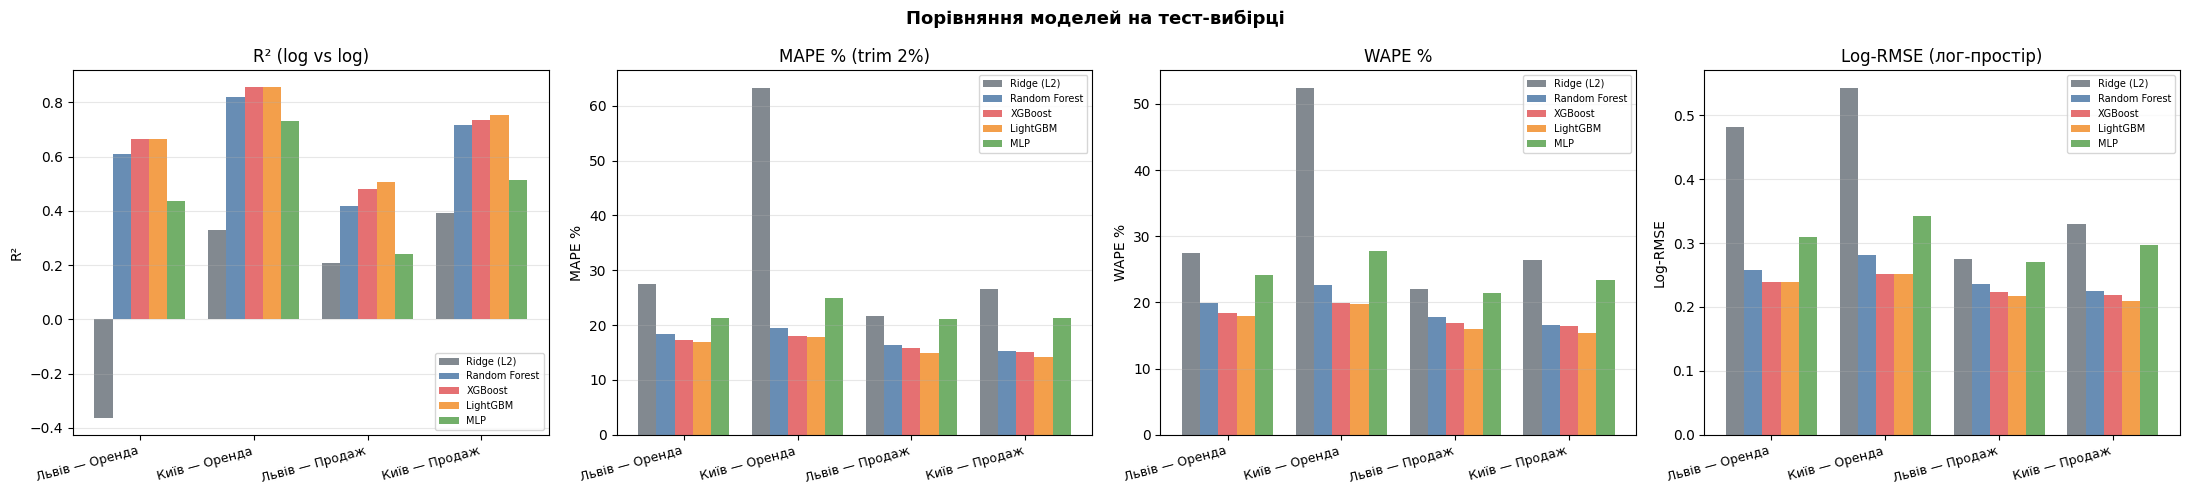

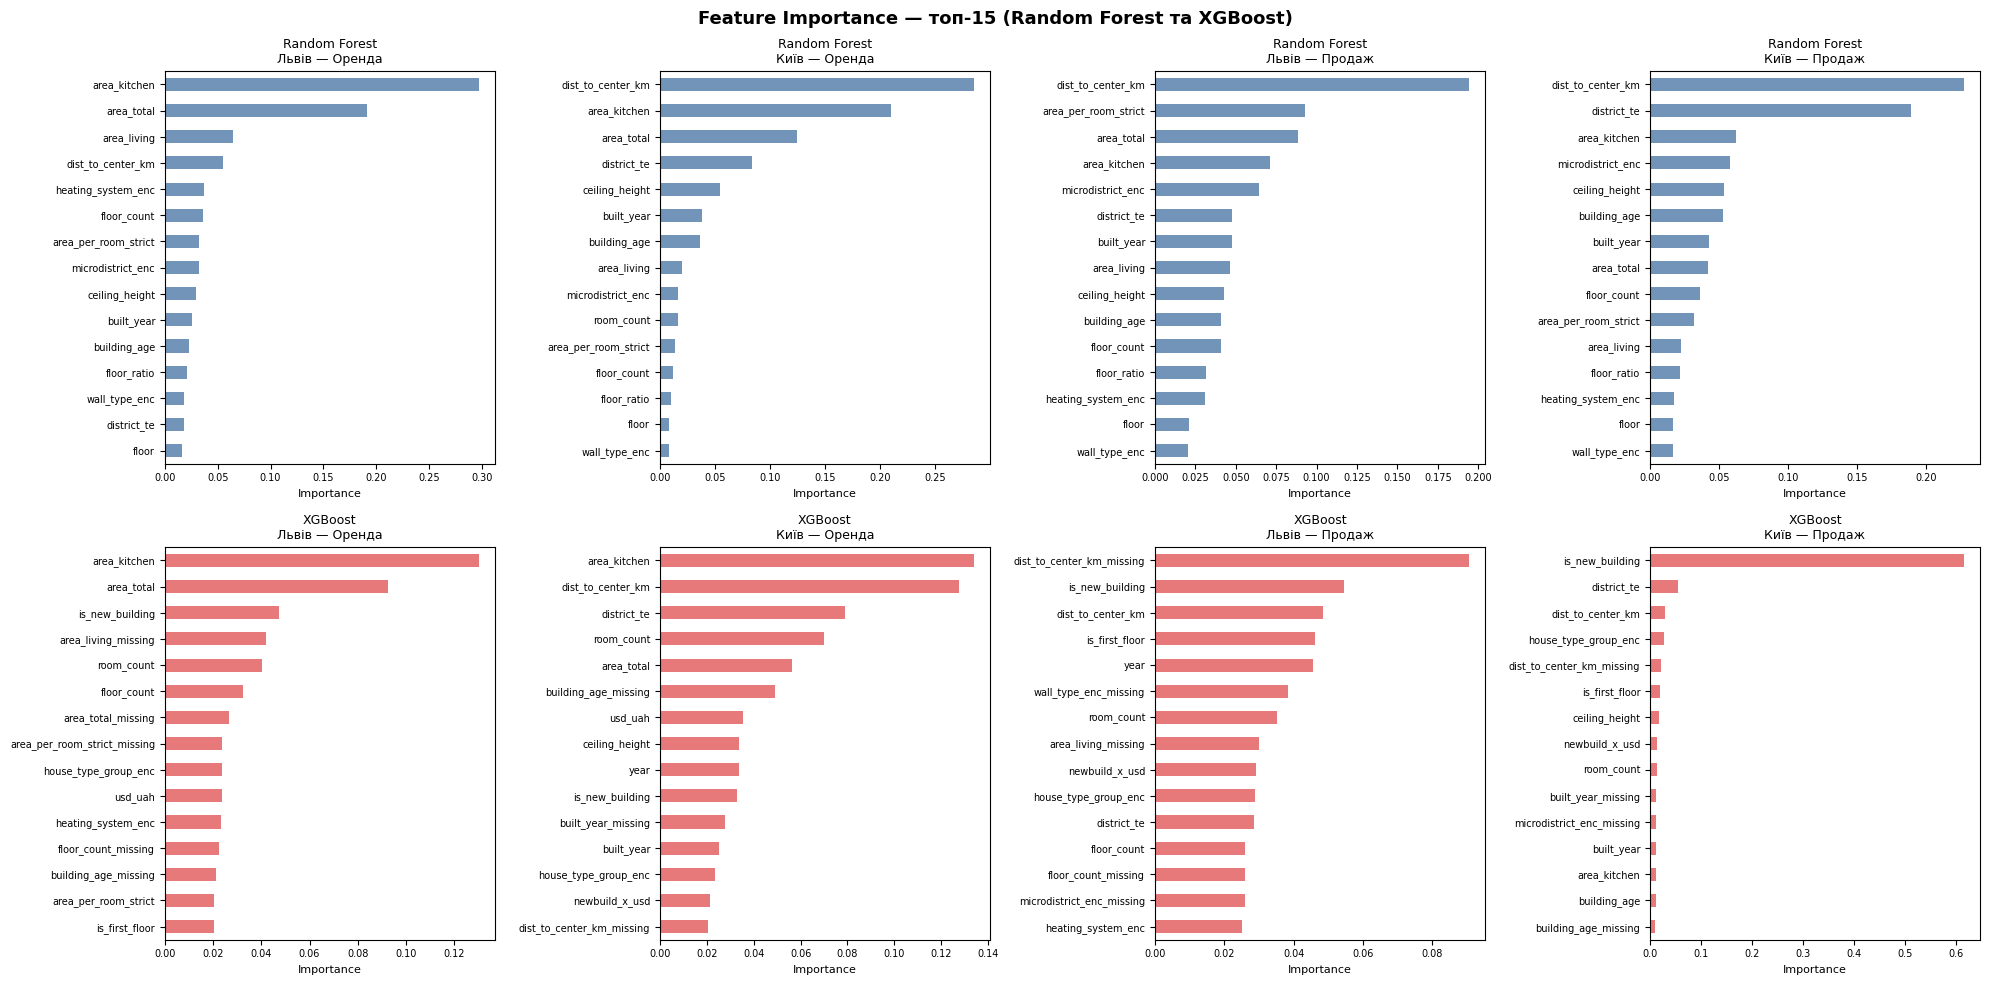

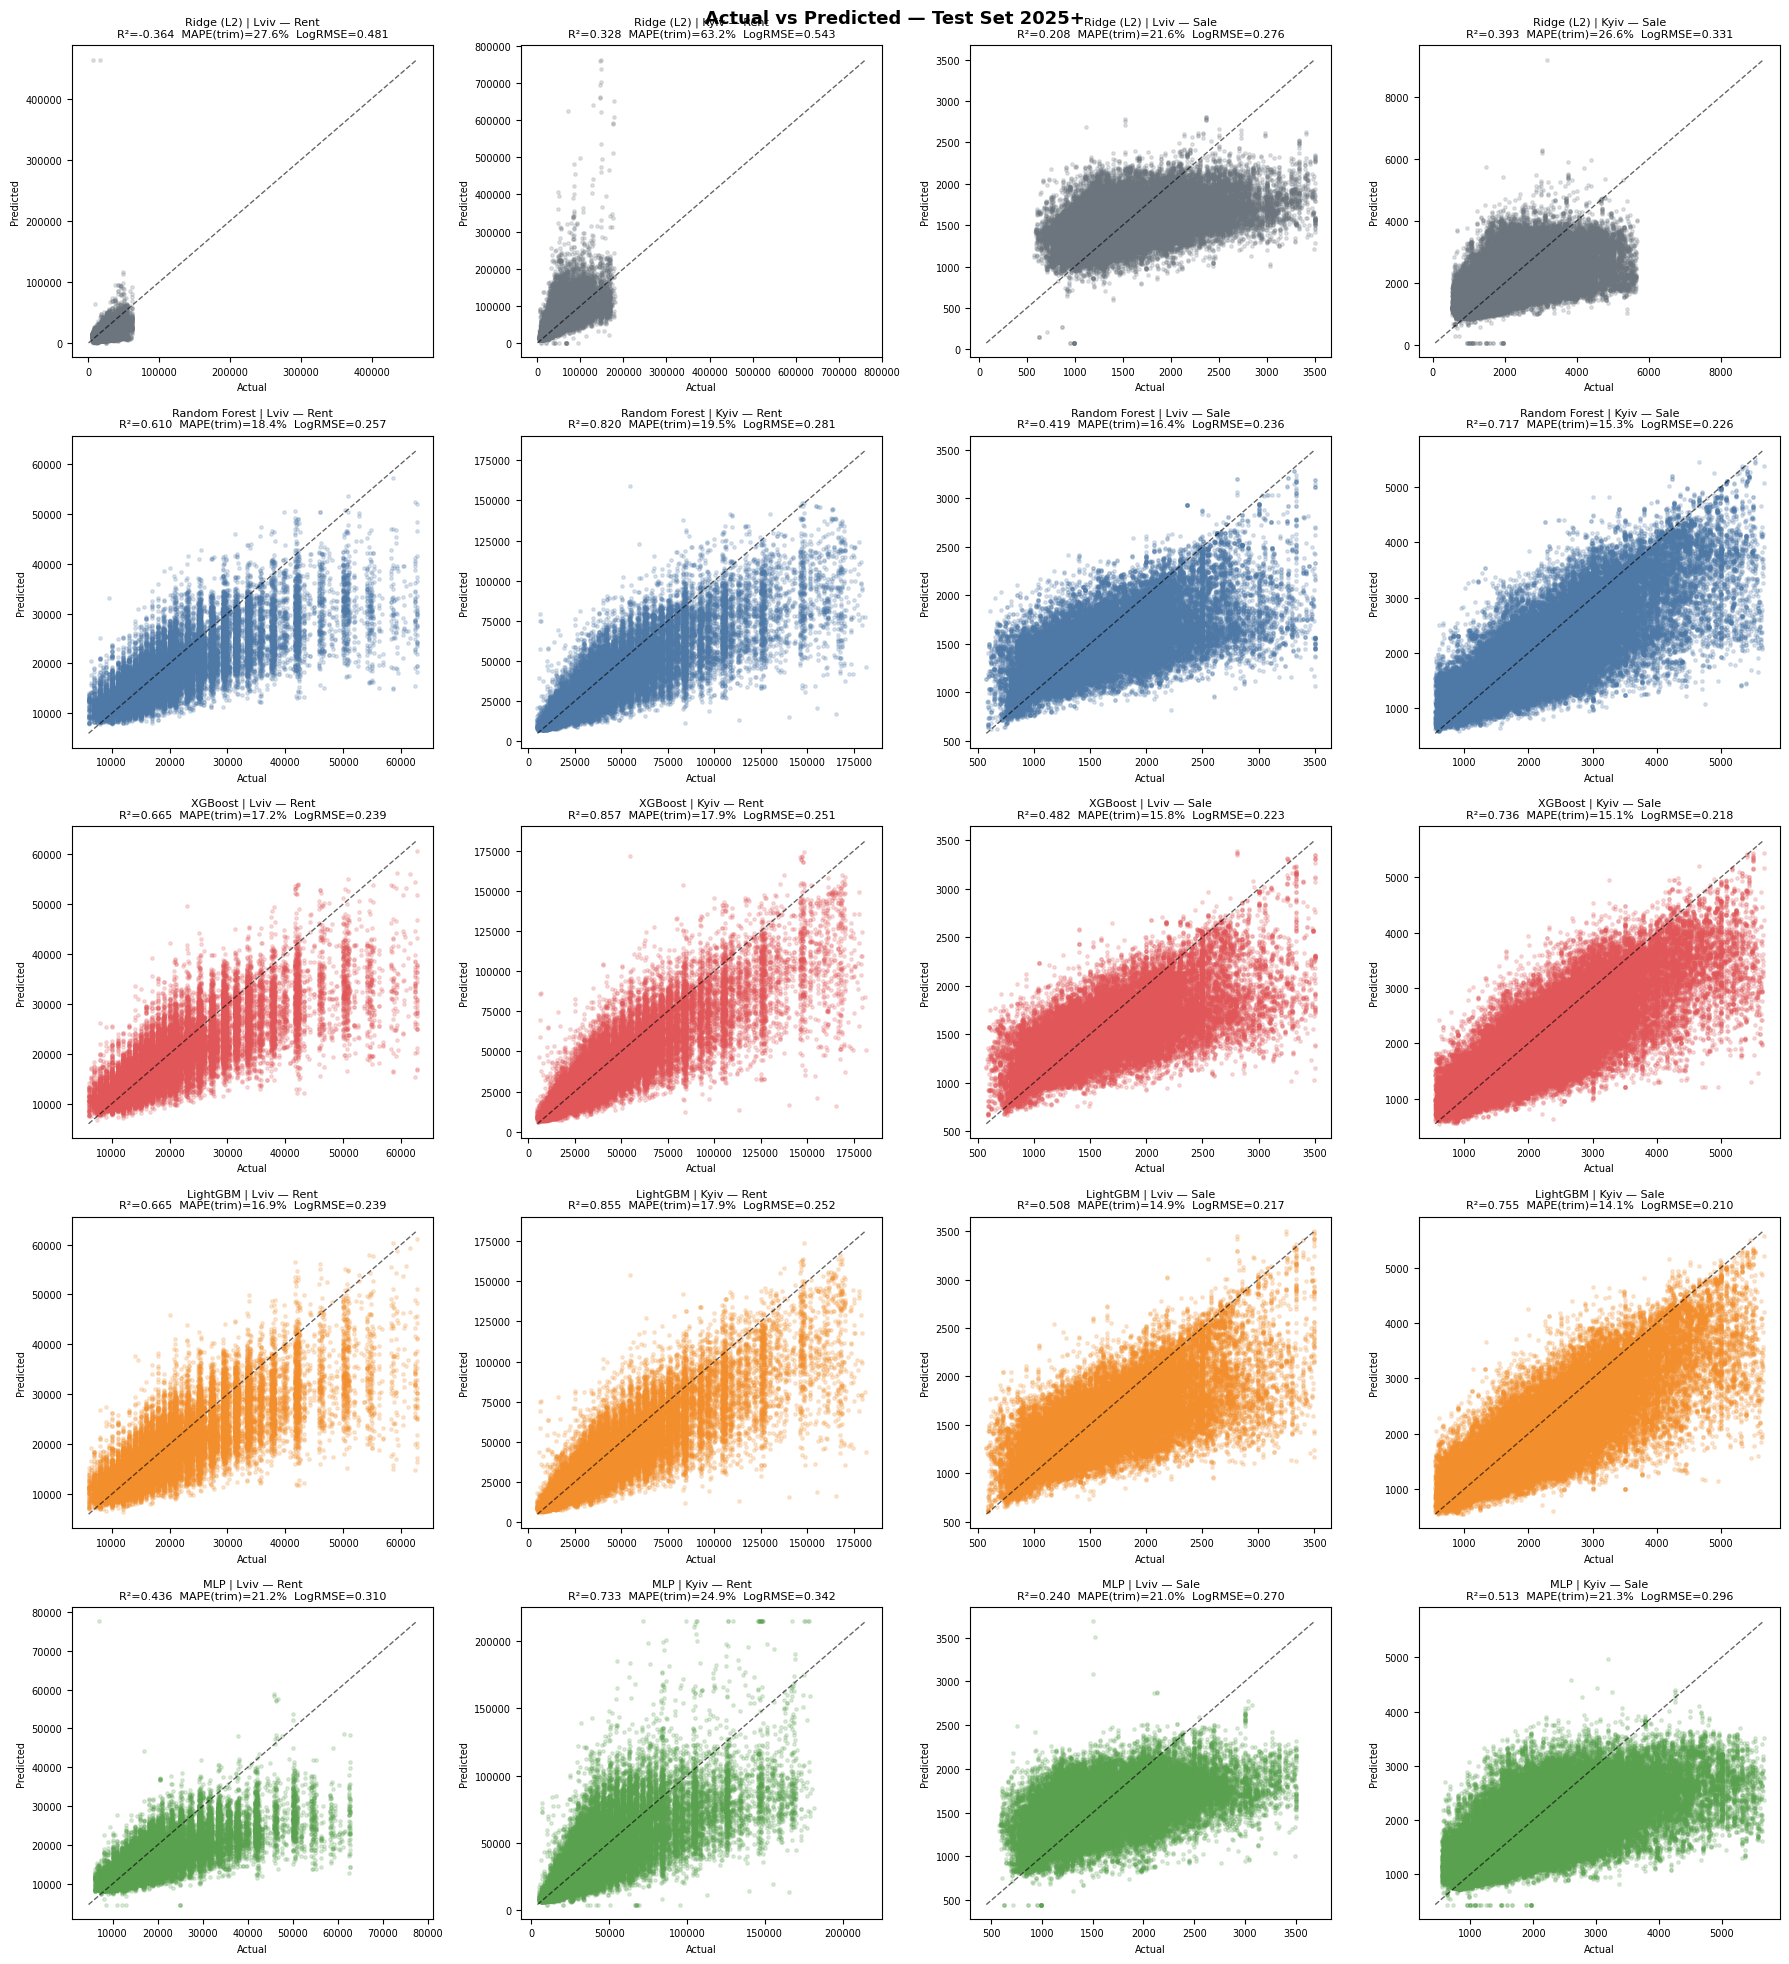

In [56]:
# ── Model comparison: summary metrics table ───────────────────────────────


def _wape_mape_trim(y_true, y_pred, trim_q=0.02):
    """WAPE + MAPE after trimming the bottom 2% of prices."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0)
    y_true, y_pred = y_true[ok], y_pred[ok]
    if len(y_true) == 0:
        return float("nan"), float("nan")
    wape = 100.0 * np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-12)
    thr = np.quantile(y_true, trim_q)
    sub = y_true >= max(thr, 1.0)
    if not np.any(sub):
        return wape, float("nan")
    mape_t = 100.0 * np.mean(np.abs((y_true[sub] - y_pred[sub]) / y_true[sub]))
    return wape, mape_t


def _log_rmse(y_true, y_pred):
    """
    RMSE in log-space — scale-invariant and robust to bias
    on inverse transformation (regression to the mean).
    log1p(expm1(x)) = x, so np.log1p(y_pred) = the original model prediction.
    """
    yt = np.log1p(np.asarray(y_true, float))
    yp = np.log1p(np.asarray(y_pred, float))
    ok = np.isfinite(yt) & np.isfinite(yp)
    return float(np.sqrt(np.mean((yt[ok] - yp[ok]) ** 2)))


all_rows = []
model_collections = [
    ('Ridge (L2)',    ridge_results),
    ('Random Forest', rf_results),
    ('XGBoost',       xgb_results),
    ('LightGBM',      lgbm_results if 'lgbm_results' in dir() else {}),
    ('MLP',           mlp_results),
]

for model_name, res_dict in model_collections:
    for (city, ctype), r in res_dict.items():
        cfg = SEG_CONFIG[(city, ctype)]
        wape, mape_t = _wape_mape_trim(r['y_test'], r['y_pred'])
        lrmse = _log_rmse(r['y_test'], r['y_pred'])
        all_rows.append({
            'Model':    model_name,
            'Segment':   cfg['label'],
            'MAE':       round(r['MAE'],  2),
            'RMSE':      round(r['RMSE'], 2),
            'R²':        round(r['R2'],   4),
            'MAPE %':    round(mape_t, 2) if np.isfinite(mape_t) else np.nan,
            'WAPE %':    round(wape,   2) if np.isfinite(wape)   else np.nan,
            'Log-RMSE':  round(lrmse,  4),
            'currency':  cfg['currency'],
        })

df_metrics = pd.DataFrame(all_rows)

print("=" * 80)
print("SUMMARY METRICS TABLE (test set 2025+)")
print("MAPE% = after trimming the bottom 2% of prices | Log-RMSE = RMSE in log1p-space")
print("=" * 80)
pivot = df_metrics.pivot_table(
    index='Segment', columns='Model',
    values=['R²', 'MAPE %', 'WAPE %', 'Log-RMSE'], aggfunc='first'
)
print(pivot.round(4).to_string())

# ── Separate Log-RMSE table ──────────────────────────────────────────────────
print("\n" + "=" * 80)
print("Log-RMSE by model and segment (lower = better, scale-invariant)")
print("=" * 80)
pv_log = df_metrics.pivot_table(
    index='Segment', columns='Model', values='Log-RMSE', aggfunc='first'
).round(4)
print(pv_log.to_string())

# ── Plots ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Model comparison on test set', fontsize=13, fontweight='bold')

models_order   = ['Ridge (L2)', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP']
model_colors   = ['#6c757d', '#4e79a7', '#e15759', '#f28e2b', '#59a14f']
segments_order = ['Lviv — Rent', 'Kyiv — Rent', 'Lviv — Sale', 'Kyiv — Sale']

x     = np.arange(len(segments_order))
width = 0.16

metrics_plot = [
    ('R²',       'R² (log vs log)'),
    ('MAPE %',   'MAPE % (trim 2%)'),
    ('WAPE %',   'WAPE %'),
    ('Log-RMSE', 'Log-RMSE (log-space)'),
]

for ax, (metric, title) in zip(axes, metrics_plot):
    for i, (m_name, m_color) in enumerate(zip(models_order, model_colors)):
        vals = []
        for s in segments_order:
            sub = df_metrics[(df_metrics['Model'] == m_name) & (df_metrics['Segment'] == s)]
            vals.append(sub[metric].values[0] if len(sub) > 0 else 0)
        ax.bar(x + i*width, vals, width, label=m_name, color=m_color, alpha=0.85)
    ax.set_title(title)
    ax.set_xticks(x + width * 2.0)
    ax.set_xticklabels(segments_order, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Feature Importance: RF + XGBoost (top-15) ────────────────────────────────
seg_order = [('Львів','Оренда'), ('Київ','Оренда'), ('Львів','Продаж'), ('Київ','Продаж')]
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))
fig2.suptitle('Feature Importance — top-15 (Random Forest and XGBoost)', fontsize=13, fontweight='bold')

for row_i, (m_name, res_dict, bar_color) in enumerate([
    ('Random Forest', rf_results,  '#4e79a7'),
    ('XGBoost',       xgb_results, '#e15759'),
]):
    for col_i, (city, ctype) in enumerate(seg_order):
        ax = axes2[row_i, col_i]
        r = res_dict.get((city, ctype))
        if r is None or 'importances' not in r:
            ax.set_visible(False)
            continue
        imp = r['importances'].sort_values(ascending=False).head(15)
        imp[::-1].plot(kind='barh', ax=ax, color=bar_color, alpha=0.8)
        ax.set_title(f"{m_name}\n{r['label']}", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_xlabel('Importance', fontsize=8)

plt.tight_layout()
plt.show()

# ── Actual vs Predicted — all 5 models ─────────────────────────────────────
_scatter_models = [
    ('Ridge (L2)',    ridge_results,  '#6c757d'),
    ('Random Forest', rf_results,    '#4e79a7'),
    ('XGBoost',       xgb_results,   '#e15759'),
    ('LightGBM',      lgbm_results if 'lgbm_results' in dir() else {}, '#f28e2b'),
    ('MLP',           mlp_results,   '#59a14f'),
]
n_models = len(_scatter_models)
fig3, axes3 = plt.subplots(n_models, 4, figsize=(18, 4*n_models))
fig3.suptitle('Actual vs Predicted — Test Set 2025+', fontsize=13, fontweight='bold')

_label_en = {
    'Lviv — Rent': 'Lviv — Rent',
    'Kyiv — Rent':  'Kyiv — Rent',
    'Lviv — Sale': 'Lviv — Sale',
    'Kyiv — Sale':  'Kyiv — Sale',
}

for row_i, (m_name, res_dict, pt_color) in enumerate(_scatter_models):
    for col_i, (city, ctype) in enumerate(seg_order):
        ax = axes3[row_i, col_i]
        r = res_dict.get((city, ctype))
        if r is None:
            ax.set_visible(False)
            continue
        yt, yp = r['y_test'], r['y_pred']
        # Clip axes at 98th pct — removes extreme outliers for visual clarity
        clip = np.nanpercentile(yt, 98)
        mask = yt <= clip
        ax.scatter(yt[mask], yp[mask], alpha=0.2, s=6, color=pt_color)
        lim_hi = np.nanpercentile(np.concatenate([yt[mask], yp[mask]]), 99)
        lim_lo = max(0, np.nanpercentile(np.concatenate([yt[mask], yp[mask]]), 0.5))
        ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, alpha=0.6)
        ax.set_xlim(lim_lo, lim_hi)
        ax.set_ylim(lim_lo, lim_hi)
        _, mt = _wape_mape_trim(yt, yp)
        lrm = _log_rmse(yt, yp)
        seg_label = _label_en.get(r['label'], r['label'])
        ax.set_title(f"{m_name} | {seg_label}\nR²={r['R2']:.3f}  MAPE(trim)={mt:.1f}%  LogRMSE={lrm:.3f}", fontsize=8)
        ax.set_xlabel('Actual',    fontsize=7)
        ax.set_ylabel('Predicted', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
import os; os.makedirs("figures", exist_ok=True)
plt.savefig("figures/actual_vs_predicted_all.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── VIF: Variance Inflation Factor for macro block ──────────────────────────
# Computed on the training partition (May 2023 – April 2025).
# All macro features are monthly aggregates, so VIF is computed on 24 months.

from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np, pandas as pd

MACRO_FEATS = [
    "usd_uah", "nbu_rate", "construction_idx_residential",
    "food_price_idx", "days_since_war",
]

# Take any segment — macro values are identical across segments
seg_key = list(seg_data.keys())[0]
X_tr_all = seg_data[seg_key]["X_train"]

macro_cols_present = [f for f in MACRO_FEATS if f in X_tr_all.columns]
macro_mat = X_tr_all[macro_cols_present].drop_duplicates().dropna().values.astype(float)

print(f"Unique monthly observations used for VIF: {len(macro_mat)}")
print()

vif_rows = []
for i, feat in enumerate(macro_cols_present):
    vif = variance_inflation_factor(macro_mat, i)
    vif_rows.append({"Feature": feat, "VIF": round(vif, 1)})

vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
print("VIF — macro block (training partition)")
print(vif_df.to_string(index=False))

print()
print("Pairwise Pearson correlations:")
print(pd.DataFrame(macro_mat, columns=macro_cols_present).corr().round(3).to_string())
print()
print("Note: VIF >> 10 is expected for monthly macro series that share a common wartime trend.")
print("For tree-based models this does not affect predictive accuracy,")
print("but SHAP attributions within the macro block are not independently interpretable.")


## 14.3 Slice-Based Evaluation — where does the model work best?

Accuracy analysis of LightGBM (best model) by subgroups:
- **Room count**: 1-room / 2-room / 3+ rooms
- **Area**: small (<40 m²) / medium (40–70 m²) / large (>70 m²)
- **District** (top-5 districts per segment)

> **Conclusion**: the model is most accurate for standard 1–2-room apartments of medium price category.
> This is the most liquid market segment with sufficient training examples.


  LGBM — MAPE% by Subgroup (test set)

── Rooms ──
Segment  Kyiv-Rent  Kyiv-Sale  Lviv-Rent  Lviv-Sale
Slice                                              
1-room        16.6       15.8       16.1       16.5
2-room        18.2       14.2       18.5       15.3
3+-room       20.6       13.9       18.9       14.2

── Area ──
Segment   Kyiv-Rent  Kyiv-Sale  Lviv-Rent  Lviv-Sale
Slice                                               
40–70 m²       17.2       14.7       16.6       15.8
<40 m²         16.5       16.2       17.8       16.6
>70 m²         20.5       14.1       18.9       14.6

── Floor ──
Segment       Kyiv-Rent  Kyiv-Sale  Lviv-Rent  Lviv-Sale
Slice                                                   
Ground floor       19.0       15.3       19.3       16.2
Middle floor       18.0       14.6       16.6       15.4
Top floor          19.6       14.8       19.2       15.5

── District ──
Segment         Kyiv-Rent  Kyiv-Sale  Lviv-Rent  Lviv-Sale
Slice                                  

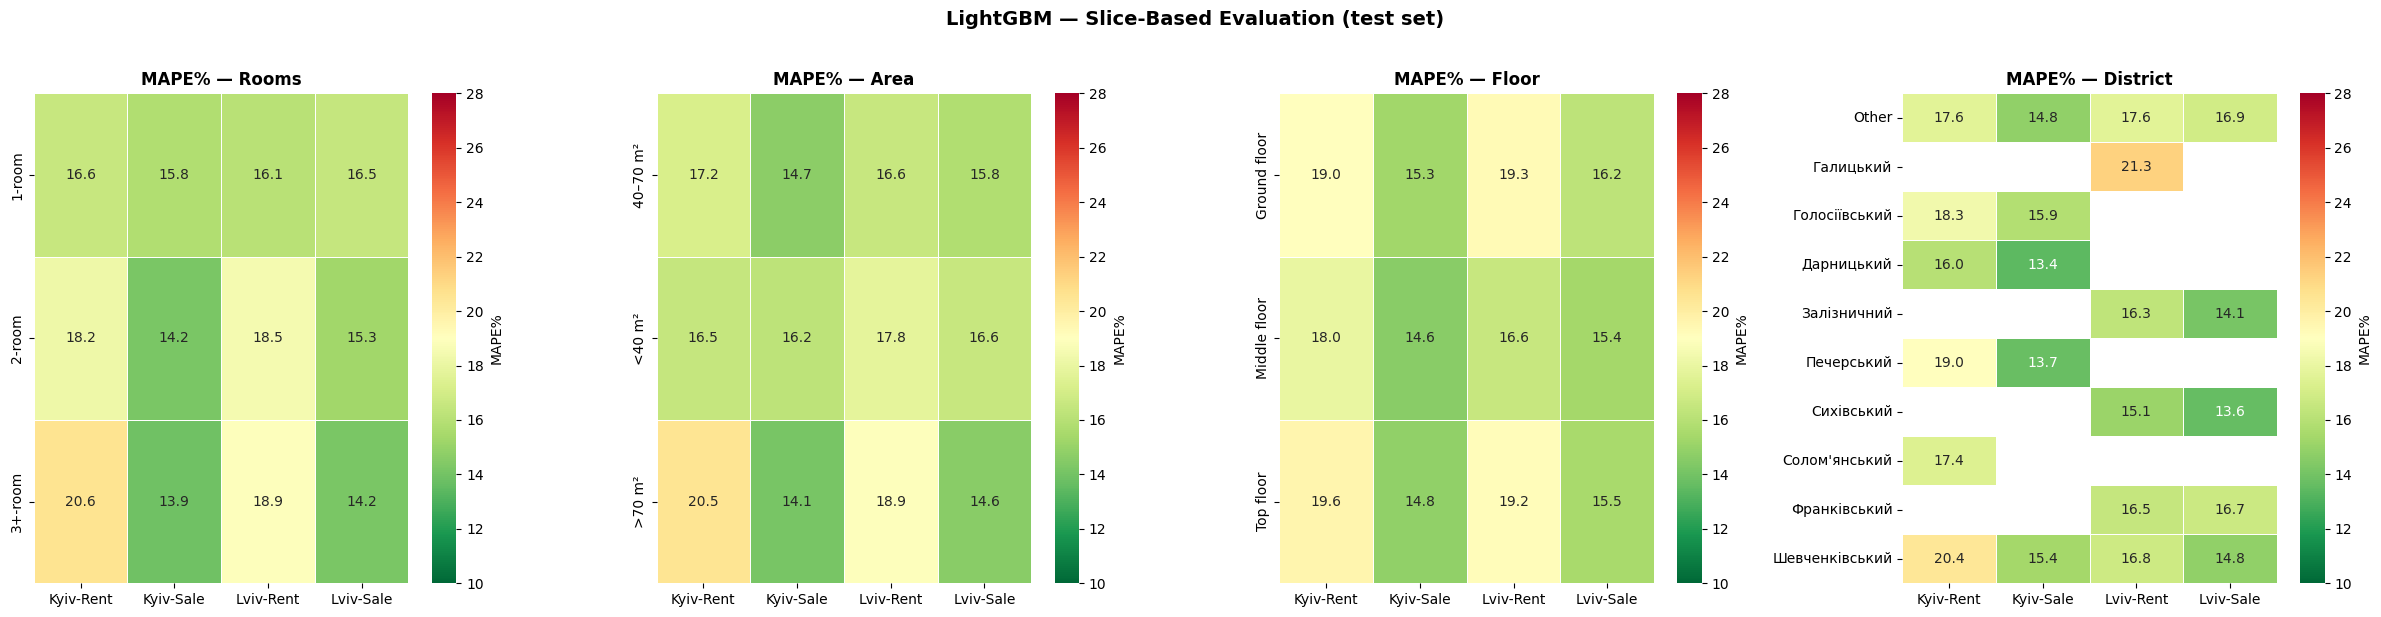


✅ Slice analysis complete — saved figures/slice_heatmaps.png


In [57]:
# ── Slice-Based Evaluation: LGBM MAPE by subgroup ──────────────────────────
# Slices only by features observable before prediction (not price!)
import warnings; warnings.filterwarnings('ignore')

SEG_LABELS_UA = {
    ('Львів', 'Оренда'): 'Lviv-Rent',
    ('Київ',  'Оренда'): 'Kyiv-Rent',
    ('Львів', 'Продаж'): 'Lviv-Sale',
    ('Київ',  'Продаж'): 'Kyiv-Sale',
}

def _mape_arr(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    ok = (y_true > 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    if ok.sum() < 5:
        return np.nan
    return float(np.mean(np.abs((y_true[ok] - y_pred[ok]) / y_true[ok])) * 100)

def slice_analysis(seg_data, lgbm_results, SEG_DATASETS):
    rows = []
    for key, res in lgbm_results.items():
        if res is None:
            continue
        label = SEG_LABELS_UA.get(key, str(key))
        y_te   = np.asarray(res['y_test'],  float)
        y_pred = np.asarray(res['y_pred'],  float)

        data    = seg_data[key]
        X_te_df = data['X_test'].copy()
        train_med = data['X_train'].median(numeric_only=True)
        X_te_df = X_te_df.replace([np.inf, -np.inf], np.nan).fillna(train_med).fillna(0.0)

        n   = min(len(y_te), len(X_te_df))
        yt  = y_te[:n]
        yp  = y_pred[:n]
        Xdf = X_te_df.iloc[:n].reset_index(drop=True)

        # ── 1. Rooms ─────────────────────────────────────────────────────────
        if 'room_count' in Xdf.columns:
            rc = Xdf['room_count'].clip(1, 5).astype(int)
            for r_val, r_label in [(1,'1-room'), (2,'2-room'), (3,'3+-room')]:
                mask = (rc == r_val) if r_val < 3 else (rc >= 3)
                rows.append({'Segment': label, 'Slice': r_label, 'Group': 'Rooms',
                             'N': int(mask.sum()), 'MAPE%': _mape_arr(yt[mask], yp[mask])})

        # ── 2. Area ──────────────────────────────────────────────────────────
        if 'area_total' in Xdf.columns:
            area = Xdf['area_total'].replace(0, np.nan).fillna(Xdf['area_total'].median())
            for lo, hi, lbl in [(0,40,'<40 m²'), (40,70,'40–70 m²'), (70,9999,'>70 m²')]:
                mask = (area >= lo) & (area < hi)
                rows.append({'Segment': label, 'Slice': lbl, 'Group': 'Area',
                             'N': int(mask.sum()), 'MAPE%': _mape_arr(yt[mask], yp[mask])})

        # ── 3. Floor ─────────────────────────────────────────────────────────
        if 'is_first_floor' in Xdf.columns and 'is_last_floor' in Xdf.columns:
            first = Xdf['is_first_floor'].astype(bool)
            last  = Xdf['is_last_floor'].astype(bool)
            mid   = ~first & ~last
            for mask, lbl in [(first,'Ground floor'), (mid,'Middle floor'), (last,'Top floor')]:
                rows.append({'Segment': label, 'Slice': lbl, 'Group': 'Floor',
                             'N': int(mask.sum()), 'MAPE%': _mape_arr(yt[mask], yp[mask])})

        # ── 4. District (from original dataset via X_test index) ─────────────
        orig_df = SEG_DATASETS.get(key)
        if orig_df is not None and 'district' in orig_df.columns:
            te_idx = data['X_test'].index[:n]
            district_raw = orig_df.loc[orig_df.index.isin(te_idx), 'district']
            # Align by position (X_test preserves original index)
            district_s = orig_df['district'].reindex(data['X_test'].index[:n]).fillna('Other').values
            # Top-5 districts by count, rest → 'Other'
            top_districts = pd.Series(district_s).value_counts().head(5).index.tolist()
            district_grouped = np.where(np.isin(district_s, top_districts), district_s, 'Other')
            for dist in top_districts + ['Other']:
                mask = district_grouped == dist
                if mask.sum() >= 10:
                    rows.append({'Segment': label, 'Slice': dist, 'Group': 'District',
                                 'N': int(mask.sum()), 'MAPE%': _mape_arr(yt[mask], yp[mask])})

    return pd.DataFrame(rows)


# ── Run ──────────────────────────────────────────────────────────────────────
if 'lgbm_results' in dir() and lgbm_results:
    df_slices = slice_analysis(seg_data, lgbm_results, SEG_DATASETS)

    # ── Table ──────────────────────────────────────────────────────────────
    print('=' * 72)
    print('  LGBM — MAPE% by Subgroup (test set)')
    print('=' * 72)
    for grp in ['Rooms', 'Area', 'Floor', 'District']:
        sub = df_slices[df_slices['Group'] == grp]
        if sub.empty:
            continue
        pv = sub.pivot_table(index='Slice', columns='Segment', values='MAPE%').round(1)
        print(f'\n── {grp} ──')
        print(pv.to_string())

    # ── Heatmaps ─────────────────────────────────────────────────────────────────
    import seaborn as sns
    groups = [g for g in ['Rooms', 'Area', 'Floor', 'District']
              if g in df_slices['Group'].values]
    fig, axes = plt.subplots(1, len(groups), figsize=(6*len(groups), 6))
    if len(groups) == 1:
        axes = [axes]

    for ax, grp in zip(axes, groups):
        sub = df_slices[df_slices['Group'] == grp]
        pv  = sub.pivot_table(index='Slice', columns='Segment', values='MAPE%').round(1)
        sns.heatmap(pv, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn_r',
                    vmin=10, vmax=28, linewidths=0.5, cbar_kws={'label': 'MAPE%'})
        ax.set_title(f'MAPE% — {grp}', fontsize=12, fontweight='bold')
        ax.set_xlabel(''); ax.set_ylabel('')

    plt.suptitle('LightGBM — Slice-Based Evaluation (test set)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    import os; os.makedirs("figures", exist_ok=True)
    plt.savefig("figures/slice_heatmaps.png", dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ Slice analysis complete — saved figures/slice_heatmaps.png')
else:
    print('⚠️  lgbm_results not found — run the LGBM cell first')


## 14.1 XGBoost Error Diagnostics

If RMSE/MAE > 3 — most of the RMSE is generated by 1-2% outliers, not by average predictions.


In [58]:
# ─────────────────────────────────────────────────────────────
# XGBoost ERROR DIAGNOSTICS — top-20 worst predictions
# Helps see WHETHER it's a data issue (outlier in test) or a modelling problem.
# ─────────────────────────────────────────────────────────────

print("=" * 78)
print("TOP-20 worst residuals per segment (XGBoost)")
print("=" * 78)

for (city, ctype), r in xgb_results.items():
    cfg = SEG_CONFIG[(city, ctype)]
    y_te = r['y_test']
    y_pr = r['y_pred']
    ape  = np.abs((y_te - y_pr) / (y_te + 1e-9)) * 100
    order = np.argsort(ape)[::-1][:20]
    print(f"\n  [{cfg['label']}]  {cfg['currency']}")
    print(f"    median APE: {np.median(ape):6.2f}%  |  p95 APE: {np.percentile(ape, 95):6.2f}%  |  p99 APE: {np.percentile(ape, 99):6.2f}%")
    print(f"    y_actual      y_pred       APE%")
    for k in order[:8]:
        print(f"    {y_te[k]:>12,.0f}  {y_pr[k]:>12,.0f}  {ape[k]:>8.1f}%")

# RMSE/MAE ratio — a "healthy" model has 1.5-2; >5 means outliers are inflating RMSE
print("\n" + "=" * 78)
print("RMSE/MAE ratio (indicator of instability due to outliers)")
print("=" * 78)
for (city, ctype), r in xgb_results.items():
    cfg = SEG_CONFIG[(city, ctype)]
    ratio = r['RMSE'] / max(r['MAE'], 1e-9)
    flag = '⚠️ outliers' if ratio > 3 else ('OK' if ratio < 2.2 else 'marginal')
    print(f"  {cfg['label']:<18}  RMSE/MAE = {ratio:>5.2f}  {flag}")


TOP-20 worst residuals per segment (XGBoost)

  [Львів — Оренда]  UAH/міс
    median APE:  14.18%  |  p95 APE:  44.80%  |  p99 APE:  68.62%
    y_actual      y_pred       APE%
           8,000        26,099     226.2%
           9,000        25,363     181.8%
           8,000        22,012     175.1%
           6,500        17,137     163.6%
           7,000        18,437     163.4%
           6,500        16,963     161.0%
          10,000        25,499     155.0%
          10,000        25,334     153.3%

  [Київ — Оренда]  UAH/міс
    median APE:  14.44%  |  p95 APE:  46.41%  |  p99 APE:  71.52%
    y_actual      y_pred       APE%
           6,500        85,756    1219.3%
           7,000        86,069    1129.6%
           6,500        69,633     971.3%
           6,500        58,990     807.5%
           6,000        46,836     680.6%
          10,500        65,095     520.0%
          10,500        64,295     512.3%
           7,000        37,620     437.4%

  [Львів — Продаж]  U

## 15. H1 Ablation (A/B/C)

Comparison of XGBoost on a single temporal split; the only difference is the feature set.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# A/B/C ABLATION — H1 evidence (do external factors add predictive value?)
#   A: internal (hedonic) features only — includes location encodings
#   B: A + macro (usd_uah, nbu_rate, construction, food_price, days_since_war)
#   C: B + security (alerts + H1-interactions + geo-safety)
# Train — up to TRAIN_END; Test — from TEST_START; gap months dropped.
# Val is NOT used here — params are fixed to isolate feature contribution.
# Fix v2:
#   1. district_te / microdistrict_enc / wall/heating/house_type_group_enc
#      added to INTERNAL_FEATS (train-only encodings, no leakage)
#   2. n_estimators increased to 3000 (lr=0.03) — enough for convergence
#      without early stopping; the previous 400 trees were clearly too few
#   3. MAPE is computed after trimming the bottom 2% of prices — as in main pipeline
# ─────────────────────────────────────────────────────────────────────────────

INTERNAL_FEATS = [
    # Structural
    'room_count', 'area_total', 'area_living', 'area_kitchen',
    'floor', 'floor_count', 'floor_ratio', 'is_first_floor', 'is_last_floor',
    'ceiling_height', 'building_age', 'is_new_building', 'built_year',
    'autonomy_score', 'has_furniture', 'has_balcony', 'has_parking',
    'has_gas', 'amenity_score', 'is_without_renovation', 'is_babushka_renovation',
    # Temporal (without wartime-specific)
    'year', 'month', 'quarter', 'month_sin', 'month_cos',
    # Location — train-only encodings (no leakage)
    'dist_to_center_km',
    'district_te', 'microdistrict_enc',
    'wall_type_enc', 'heating_system_enc', 'house_type_group_enc',
]
MACRO_FEATS = [
    'usd_uah', 'nbu_rate', 'construction_idx_residential',
    'construction_idx_total', 'food_price_idx', 'days_since_war',
]
SECURITY_FEATS = [
    'alert_count_month', 'alert_duration_h_month', 'alert_days_month',
    'alert_count_cumulative', 'alert_ratio',
    'dist_to_shelter_km', 'dist_to_subway_km', 'subway_count_1km',
    'is_wartime',
    'autonomy_x_alerts', 'autonomy_x_wartime',
    'newbuild_x_usd', 'shelter_x_alerts',
    'log_days_x_log_usd', 'era_ord_x_center',
]

CONFIGS = {
    'A (internal only)': INTERNAL_FEATS,
    'B (+ macro)':       INTERNAL_FEATS + MACRO_FEATS,
    'C (+ security)':    INTERNAL_FEATS + MACRO_FEATS + SECURITY_FEATS,
}


def _ablation_eval(df_seg, target, feats):
    df = df_seg.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df = df.dropna(subset=['date', target])
    df = drop_gaps(df)
    use = [f for f in feats if f in df.columns]
    tr = df[split_mask(df, 'train')]
    te = df[split_mask(df, 'test')]
    if len(tr) < 200 or len(te) < 50 or XGBRegressor is None:
        return None

    X_tr_raw = _coerce_numeric_frame(tr, use)
    X_te_raw = _coerce_numeric_frame(te, use)
    med = X_tr_raw.median(numeric_only=True)
    X_tr = X_tr_raw.replace([np.inf, -np.inf], np.nan).fillna(med).fillna(0.0)
    X_te = X_te_raw.replace([np.inf, -np.inf], np.nan).fillna(med).fillna(0.0)
    y_tr = np.log1p(tr[target].values)
    y_te = te[target].values

    # Fix 2: 3000 trees — enough for convergence without early stopping
    m = XGBRegressor(
        n_estimators=3000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, n_jobs=-1,
        random_state=RANDOM_STATE, verbosity=0,
    )
    m.fit(X_tr, y_tr)
    y_pred = np.expm1(m.predict(X_te))

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    # Fix 3: MAPE with 2% trim — as in main pipeline
    mask_trim = y_te >= np.percentile(y_te, 2)
    mape = 100.0 * np.mean(
        np.abs((y_te[mask_trim] - y_pred[mask_trim]) / (y_te[mask_trim] + 1e-9))
    )
    wape = 100.0 * np.sum(np.abs(y_te - y_pred)) / (np.sum(np.abs(y_te)) + 1e-9)
    return {'n_feats': len(use), 'MAE': mae, 'RMSE': rmse, 'MAPE%': mape, 'WAPE%': wape}


if 'SEG_DATASETS' in globals() and 'SEG_CONFIG' in globals():
    ablation_rows = []
    for (city, ctype), df_seg in SEG_DATASETS.items():
        cfg = SEG_CONFIG[(city, ctype)]
        for cfg_name, feats in CONFIGS.items():
            r = _ablation_eval(df_seg, cfg['target'], feats)
            if r is None:
                continue
            ablation_rows.append({
                'Segment': cfg['label'], 'Config': cfg_name,
                'n_feat': r['n_feats'],
                'RMSE': round(r['RMSE'], 2),
                'MAPE%': round(r['MAPE%'], 2),
                'WAPE%': round(r['WAPE%'], 2),
            })

    abl = pd.DataFrame(ablation_rows)
    print("=" * 78)
    print(f"ABLATION v2 (XGBoost 3000 trees | train ≤ {TRAIN_END.date()} | test ≥ {TEST_START.date()} | gaps dropped)")
    print("=" * 78)
    print(abl.pivot_table(
        index='Segment', columns='Config',
        values=['RMSE', 'MAPE%', 'WAPE%'], aggfunc='first',
    ).round(2).to_string())

    def _delta(seg, metric, a, b):
        va = abl[(abl['Segment']==seg) & (abl['Config']==a)][metric]
        vb = abl[(abl['Segment']==seg) & (abl['Config']==b)][metric]
        if len(va)==0 or len(vb)==0: return float('nan')
        return round(vb.values[0] - va.values[0], 2)

    delta_rows = []
    for seg in abl['Segment'].unique():
        delta_rows.append({
            'Segment': seg,
            'Δ MAPE (B−A) macro':    _delta(seg, 'MAPE%', 'A (internal only)', 'B (+ macro)'),
            'Δ MAPE (C−B) security': _delta(seg, 'MAPE%', 'B (+ macro)',       'C (+ security)'),
            'Δ MAPE (C−A) total':    _delta(seg, 'MAPE%', 'A (internal only)', 'C (+ security)'),
            'Δ RMSE (B−A)':          _delta(seg, 'RMSE',  'A (internal only)', 'B (+ macro)'),
            'Δ RMSE (C−B)':          _delta(seg, 'RMSE',  'B (+ macro)',       'C (+ security)'),
        })
    print("\n=== H1 — gain from external blocks (negative Δ = improvement) ===")
    print(pd.DataFrame(delta_rows).to_string(index=False))
else:
    print("⚠️ Skipped: SEG_DATASETS/SEG_CONFIG not yet defined.")


ABLATION v2 (XGBoost 3000 trees | train ≤ 2025-04-30 | test ≥ 2025-10-01 | gaps dropped)
                           MAPE%                                         RMSE                                        WAPE%                           
Config         A (internal only) B (+ macro) C (+ security) A (internal only) B (+ macro) C (+ security) A (internal only) B (+ macro) C (+ security)
Сегмент                                                                                                                                              
Kyiv  — Rental             20.26       20.37          20.07          11731.77    11715.54       11661.37             21.71       21.81          21.57
Kyiv  — Sale               17.52       17.37          17.31            541.08      532.60         531.29             19.43       19.14          19.07
Lviv — Rental              18.00       18.07          18.01           6005.17     6041.89        6027.51             19.35       19.53          19.48
Lviv — Sale

## 16. SHAP — Interpretation

Below — **global** feature importance (mean |SHAP|) for a trained XGBoost on a selected segment. A random sub-sample of the test set is used for speed.

Required packages: `pip install shap` (if not yet installed).


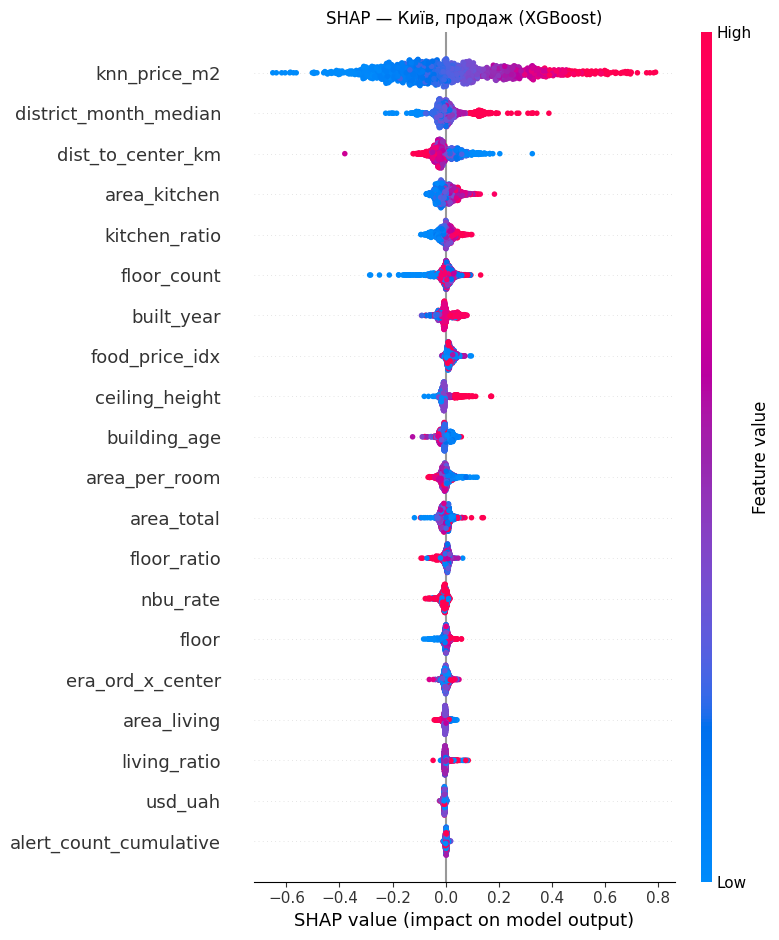

In [15]:
try:
    import shap

    demo_key = ("Київ", "Продаж")
    if demo_key in xgb_results and xgb_results[demo_key] is not None:
        m = xgb_results[demo_key]["model"]
        X_te = seg_data[demo_key]["X_test"]
        sample = X_te.sample(min(1500, len(X_te)), random_state=42)
        explainer = shap.TreeExplainer(m)
        sv = explainer.shap_values(sample)
        shap.summary_plot(sv, sample, show=False, max_display=20)
        plt.title("SHAP — Kyiv, sale (XGBoost)")
        plt.tight_layout()
        plt.show()
    else:
        print("No trained XGBoost for demo key", demo_key)
except ImportError:
    print("Package shap not installed. Run: pip install shap")
except Exception as e:
    print("SHAP:", repr(e))


## 16.1 SHAP — LightGBM

Comparison with XGBoost: does LightGBM (GOSS) prioritize security / macro features differently?


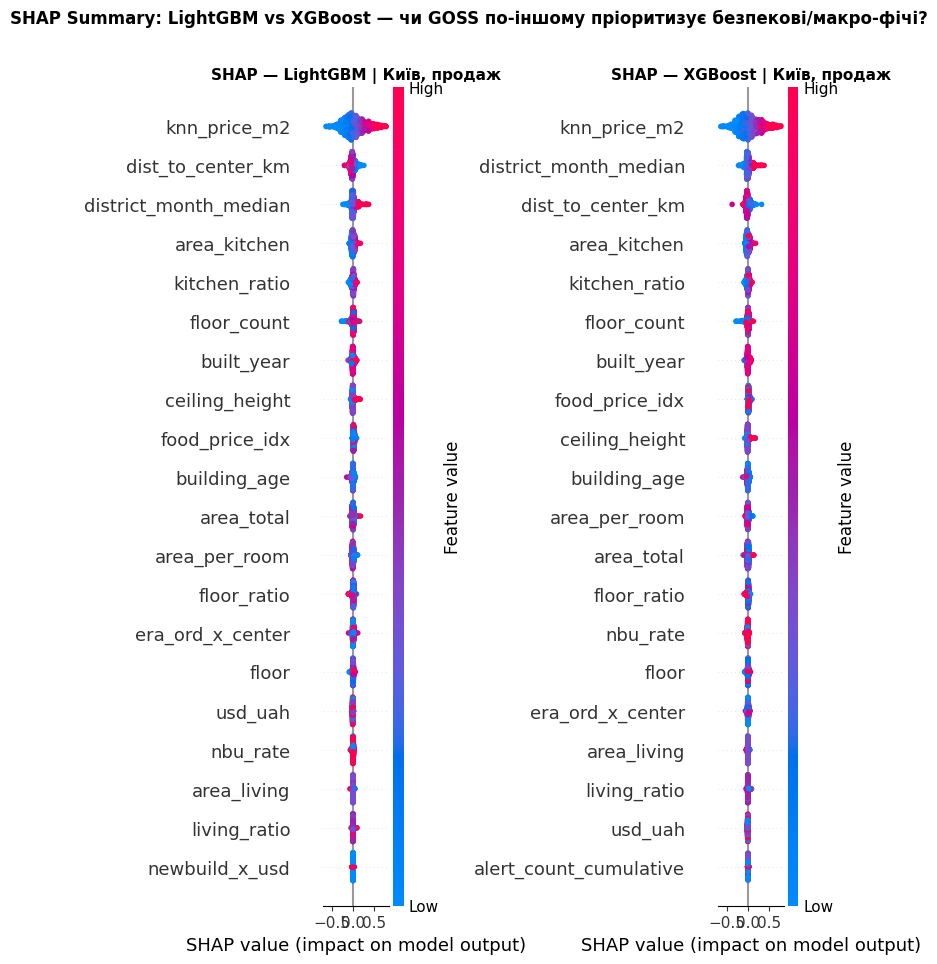

In [16]:
try:
    import shap

    demo_key = ("Київ", "Продаж")
    if 'lgbm_results' in dir() and demo_key in lgbm_results and lgbm_results[demo_key] is not None:
        m_lgbm = lgbm_results[demo_key]["model"]
        X_te_lgbm = seg_data[demo_key]["X_test"]
        train_med_lgbm = seg_data[demo_key]["X_train"].median(numeric_only=True)
        X_te_lgbm = X_te_lgbm.replace([np.inf, -np.inf], np.nan).fillna(train_med_lgbm).fillna(0.0)
        sample_lgbm = X_te_lgbm.sample(min(1500, len(X_te_lgbm)), random_state=42)

        explainer_lgbm = shap.TreeExplainer(m_lgbm)
        sv_lgbm = explainer_lgbm.shap_values(sample_lgbm)

        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        plt.sca(axes[0])
        shap.summary_plot(sv_lgbm, sample_lgbm, show=False, max_display=20)
        axes[0].set_title("SHAP — LightGBM | Kyiv, sale", fontsize=11, fontweight='bold')

        # XGBoost side-by-side for direct comparison
        if demo_key in xgb_results and xgb_results[demo_key] is not None:
            m_xgb = xgb_results[demo_key]["model"]
            X_te_xgb = seg_data[demo_key]["X_test"]
            X_te_xgb = X_te_xgb.replace([np.inf, -np.inf], np.nan).fillna(train_med_lgbm).fillna(0.0)
            sample_xgb = X_te_xgb.sample(min(1500, len(X_te_xgb)), random_state=42)
            explainer_xgb = shap.TreeExplainer(m_xgb)
            sv_xgb = explainer_xgb.shap_values(sample_xgb)
            plt.sca(axes[1])
            shap.summary_plot(sv_xgb, sample_xgb, show=False, max_display=20)
            axes[1].set_title("SHAP — XGBoost | Kyiv, sale", fontsize=11, fontweight='bold')
        else:
            axes[1].set_visible(False)

        plt.suptitle("SHAP Summary: LightGBM vs XGBoost — does GOSS prioritize security/macro features differently?",
                     fontsize=12, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        print("No trained LightGBM for demo key", demo_key)
except ImportError:
    print("Package shap not installed. Run: pip install shap")
except Exception as e:
    print("SHAP LightGBM:", repr(e))


## 16.2 SHAP Beeswarm — all 4 segments (LightGBM)


In [17]:
import shap
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

seg_map = [
    (("Київ",  "Оренда"), "Kyiv_Rental"),
    (("Київ",  "Продаж"), "Kyiv_Sale"),
    (("Львів", "Оренда"), "Lviv_Rental"),
    (("Львів", "Продаж"), "Lviv_Sale"),
]

results_dict = lgbm_results if 'lgbm_results' in dir() else xgb_results

for (city, ctype), seg_name in seg_map:
    key = (city, ctype)
    if key not in results_dict or results_dict[key] is None:
        print(f"Skipping {key} — no model")
        continue

    model     = results_dict[key]["model"]
    X_te      = seg_data[key]["X_test"]
    train_med = seg_data[key]["X_train"].median(numeric_only=True)
    X_te      = X_te.replace([float("inf"), float("-inf")], float("nan")).fillna(train_med).fillna(0.0)
    sample    = X_te.sample(min(2000, len(X_te)), random_state=42)

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer(sample)          # Explanation object (new API)

    shap.plots.beeswarm(shap_vals, max_display=12, show=False)
    plt.title(f"SHAP feature importance — {seg_name.replace('_', ' ')}")
    plt.gcf().set_size_inches(10, 7)
    plt.tight_layout()
    plt.savefig(f"figures/shap_beeswarm_{seg_name}.png", dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved figures/shap_beeswarm_{seg_name}.png")


Збережено figures/shap_beeswarm_Kyiv_Rental.png
Збережено figures/shap_beeswarm_Kyiv_Sale.png
Збережено figures/shap_beeswarm_Lviv_Rental.png
Збережено figures/shap_beeswarm_Lviv_Sale.png


## 17. Saving the artefact (df_feat)

After a full run, save `df_feat` to Parquet for **batch scoring**, backup, or model re-entry.


In [18]:
# def new_func():
#     # Save the prepared DataFrame to Parquet (faster and smaller than CSV)
#     _ROOT = pathlib.Path('.').resolve()
#     output_path = str(_ROOT / 'df_feat_653k.parquet')
#     df_feat.to_parquet(output_path, index=False)
#     print(f"✅ Saved: {output_path}")
#     print(f"   Rows: {len(df_feat):,}")
#     print(f"   Columns: {len(df_feat.columns)}")
#     print(f"   Size: {df_feat.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# new_func()

## 14.2 Training / Validation Loss Curves

Overfitting diagnostics:
- **XGBoost** — RMSE on train vs val per boosting iteration (red = early stopping point)
- **MLP** — MSE on train vs val per epoch (partial_fit, scaled log-target)
- **Ridge** — MSE on train vs val across α-grid (where `α*` is chosen for the final model)


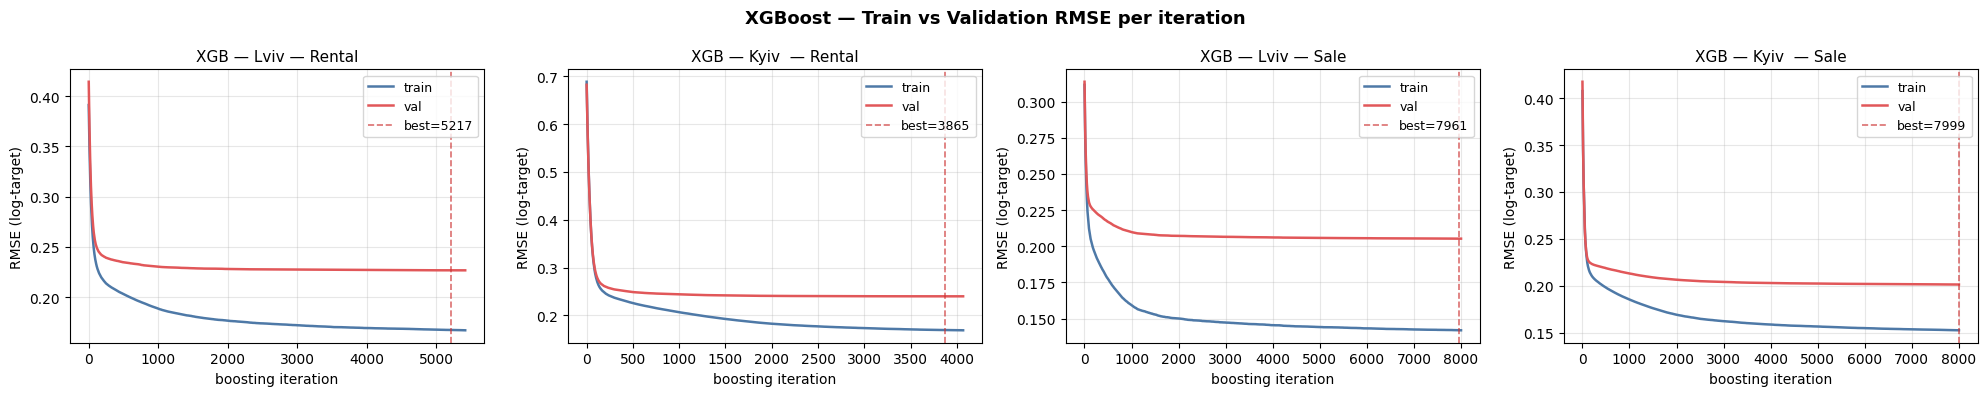

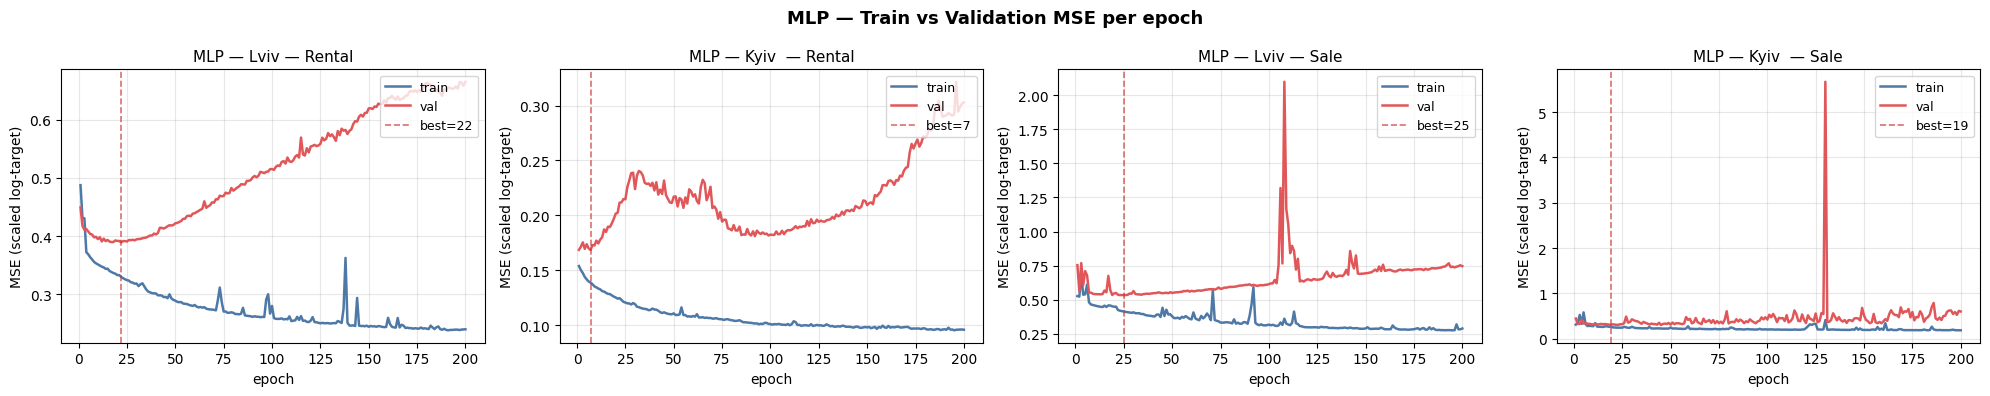

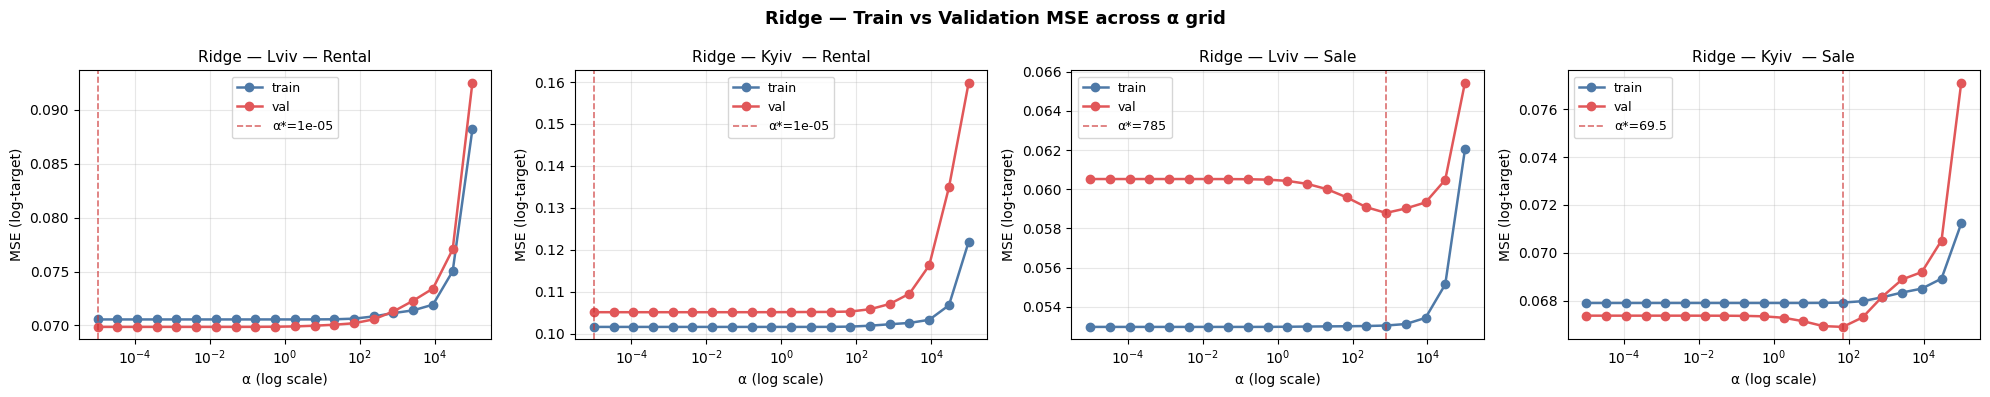


✅ Loss curves побудовано для XGB / MLP / Ridge по всіх 4 сегментах


In [19]:
# ─── Train / Val loss curves for XGB, MLP, Ridge ──────────────────────────
#   Does not modify existing *_results. Performs lightweight re-fit with history tracking.

seg_keys = [('Львів','Оренда'), ('Київ','Оренда'), ('Львів','Продаж'), ('Київ','Продаж')]
seg_keys = [k for k in seg_keys if seg_data.get(k) is not None]

# ═══════════════════════════════════════════════════════════════════════════
# 1. XGBoost: train vs val RMSE per iteration
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(seg_keys), figsize=(5*len(seg_keys), 4), sharey=False)
if len(seg_keys) == 1: axes = [axes]

for ax, key in zip(axes, seg_keys):
    d = seg_data[key]; cfg = SEG_CONFIG[key]
    X_tr = d['X_train'].replace([np.inf,-np.inf], np.nan)
    X_va = d['X_val'].replace([np.inf,-np.inf], np.nan)
    med = X_tr.median(numeric_only=True)
    X_tr = X_tr.fillna(med).fillna(0.0)
    X_va = X_va.fillna(med).fillna(0.0)
    y_tr = np.log1p(d['y_train'].values)
    y_va = np.log1p(d['y_val'].values)

    m = XGBRegressor(
        n_estimators=8000, learning_rate=0.02, max_depth=8,
        subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.5, gamma=0.05,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
        tree_method='hist', objective='reg:squarederror', eval_metric='rmse',
        early_stopping_rounds=200,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=False)
    hist = m.evals_result()
    tr_rmse = hist['validation_0']['rmse']
    va_rmse = hist['validation_1']['rmse']
    best_iter = int(m.best_iteration or (len(tr_rmse)-1))

    iters = np.arange(1, len(tr_rmse)+1)
    ax.plot(iters, tr_rmse, label='train', color='#4e79a7', lw=1.8)
    ax.plot(iters, va_rmse, label='val',   color='#e15759', lw=1.8)
    ax.axvline(best_iter+1, color='#c33', ls='--', lw=1.2, alpha=0.7,
               label=f'best={best_iter+1}')
    ax.set_title(f"XGB — {cfg['label']}", fontsize=11)
    ax.set_xlabel('boosting iteration'); ax.set_ylabel('RMSE (log-target)')
    ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper right')

fig.suptitle('XGBoost — Train vs Validation RMSE per iteration', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# 2. MLP: train vs val MSE per epoch (partial_fit loop)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(seg_keys), figsize=(5*len(seg_keys), 4), sharey=False)
if len(seg_keys) == 1: axes = [axes]

for ax, key in zip(axes, seg_keys):
    d = seg_data[key]; cfg = SEG_CONFIG[key]
    X_tr = pd.DataFrame(d['X_train']).replace([np.inf,-np.inf], np.nan).fillna(0.0).values
    X_va = pd.DataFrame(d['X_val']).replace([np.inf,-np.inf], np.nan).fillna(0.0).values
    y_tr_log = np.log1p(np.clip(d['y_train'].values.astype(float), 0, None))
    y_va_log = np.log1p(np.clip(d['y_val'].values.astype(float),   0, None))

    x_sc = StandardScaler().fit(X_tr)
    y_sc = StandardScaler().fit(y_tr_log.reshape(-1,1))
    X_tr_s = x_sc.transform(X_tr); X_va_s = x_sc.transform(X_va)
    y_tr_s = y_sc.transform(y_tr_log.reshape(-1,1)).ravel()
    y_va_s = y_sc.transform(y_va_log.reshape(-1,1)).ravel()

    mlp = MLPRegressor(
        hidden_layer_sizes=(256,128,64), activation='relu', solver='adam',
        learning_rate_init=5e-4, alpha=1e-4, batch_size='auto',
        max_iter=1, warm_start=True, random_state=RANDOM_STATE, verbose=False,
    )
    mlp.fit(X_tr_s, y_tr_s)
    tr_hist, va_hist = [], []
    EPOCHS = 200
    for _ in range(EPOCHS):
        mlp.partial_fit(X_tr_s, y_tr_s)
        tr_hist.append(mean_squared_error(y_tr_s, mlp.predict(X_tr_s)))
        va_hist.append(mean_squared_error(y_va_s, mlp.predict(X_va_s)))
    best_ep = int(np.argmin(va_hist)) + 1

    eps = np.arange(1, EPOCHS+1)
    ax.plot(eps, tr_hist, label='train', color='#4e79a7', lw=1.8)
    ax.plot(eps, va_hist, label='val',   color='#e15759', lw=1.8)
    ax.axvline(best_ep, color='#c33', ls='--', lw=1.2, alpha=0.7, label=f'best={best_ep}')
    ax.set_title(f"MLP — {cfg['label']}", fontsize=11)
    ax.set_xlabel('epoch'); ax.set_ylabel('MSE (scaled log-target)')
    ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper right')

fig.suptitle('MLP — Train vs Validation MSE per epoch', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# 3. Ridge: train vs val MSE vs α
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.pipeline import Pipeline
RIDGE_ALPHAS = list(np.logspace(-5, 5, 20))  # from 1e-5 to 1e5, 20 points

fig, axes = plt.subplots(1, len(seg_keys), figsize=(5*len(seg_keys), 4), sharey=False)
if len(seg_keys) == 1: axes = [axes]

for ax, key in zip(axes, seg_keys):
    d = seg_data[key]; cfg = SEG_CONFIG[key]
    X_tr = pd.DataFrame(d['X_train']).replace([np.inf,-np.inf], np.nan)
    X_va = pd.DataFrame(d['X_val']).replace([np.inf,-np.inf], np.nan)
    med = X_tr.median(numeric_only=True)
    X_tr = X_tr.fillna(med).fillna(0.0); X_va = X_va.fillna(med).fillna(0.0)
    y_tr = np.log1p(d['y_train'].values); y_va = np.log1p(d['y_val'].values)

    tr_mse, va_mse = [], []
    for a in RIDGE_ALPHAS:
        pipe = Pipeline([('sc', StandardScaler()), ('rg', Ridge(alpha=a, random_state=RANDOM_STATE))])
        pipe.fit(X_tr, y_tr)
        tr_mse.append(mean_squared_error(y_tr, pipe.predict(X_tr)))
        va_mse.append(mean_squared_error(y_va, pipe.predict(X_va)))
    best_idx = int(np.argmin(va_mse))
    best_a = RIDGE_ALPHAS[best_idx]

    ax.plot(RIDGE_ALPHAS, tr_mse, 'o-', label='train', color='#4e79a7', lw=1.8)
    ax.plot(RIDGE_ALPHAS, va_mse, 'o-', label='val',   color='#e15759', lw=1.8)
    ax.axvline(best_a, color='#c33', ls='--', lw=1.2, alpha=0.7, label=f'α*={best_a:.3g}')
    ax.set_xscale('log')
    ax.set_title(f"Ridge — {cfg['label']}", fontsize=11)
    ax.set_xlabel('α (log scale)'); ax.set_ylabel('MSE (log-target)')
    ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9, loc='best')

fig.suptitle('Ridge — Train vs Validation MSE across α grid', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n✅ Loss curves plotted for XGB / MLP / Ridge across all 4 segments')


## 18. Variant B (Robustness) — Pooled modeling

**Research question.** Is the **per-segment** approach (4 separate XGBoost models for Kyiv-rent, Kyiv-sale, Lviv-rent, Lviv-sale) justified — or can we pool the data into a single model without loss of accuracy?

**Experimental design.**
- We pool within a single contract_type (rent/sale), since they have different target units (`price_uah` vs `price_m2_usd`).
- Target and features are unchanged — only concat(Kyiv, Lviv) train/val/test.
- `city_enc` is already among the features → the model can identify the city.
- Same XGBoost pipeline: early stopping on pooled-val, refit on pooled train+val.
- Metrics are computed **per-segment** on test (to compare with `xgb_results` from cell 77).

**Hypothesis.** Pooled will lose to per-segment on Lviv-sale (there's market-specific behaviour there), but may win on Lviv-rent (where the abundance of Kyiv data may add regularisation).


In [20]:
# ── Variant B (Robustness): pooled XGBoost in-contract-type ──────────────────
# Two pooled models: rent (Lviv+Kyiv) and sale (Lviv+Kyiv)
# seg_data from cell 77 contains X_train/val/test, y_*, features, target
# city_enc — already among features; the model will distinguish cities itself

assert 'seg_data' in globals() and 'xgb_results' in globals(), \
    "First run cell 77 (per-segment XGB)."

def _pool_pair(key_lviv, key_kyiv):
    """Concat Lviv+Kyiv segments (same contract_type)."""
    dL = seg_data[key_lviv]; dK = seg_data[key_kyiv]
    if dL is None or dK is None:
        return None
    feats = sorted(set(dL["features"]) & set(dK["features"]))
    def _cat(a, b, cols):
        return pd.concat([a[cols], b[cols]], axis=0).reset_index(drop=True)
    X_tr = _cat(dL["X_train"], dK["X_train"], feats)
    X_va = _cat(dL["X_val"],   dK["X_val"],   feats)
    X_te = _cat(dL["X_test"],  dK["X_test"],  feats)
    y_tr = pd.concat([dL["y_train"], dK["y_train"]], axis=0).reset_index(drop=True)
    y_va = pd.concat([dL["y_val"],   dK["y_val"]],   axis=0).reset_index(drop=True)
    y_te = pd.concat([dL["y_test"],  dK["y_test"]],  axis=0).reset_index(drop=True)
    # city label for per-segment slicing on test
    city_te = pd.Series(
        ["Львів"] * len(dL["X_test"]) + ["Київ"] * len(dK["X_test"])
    )
    return dict(X_tr=X_tr, X_va=X_va, X_te=X_te,
                y_tr=y_tr.values, y_va=y_va.values, y_te=y_te.values,
                city_te=city_te, features=feats,
                keys=(key_lviv, key_kyiv))

POOLED_CONFIGS = {
    "Rent (pooled)": _pool_pair(("Львів", "Оренда"), ("Київ", "Оренда")),
    "Sale (pooled)": _pool_pair(("Львів", "Продаж"), ("Київ", "Продаж")),
}

common_params = dict(
    n_estimators=4000, learning_rate=0.02, max_depth=8,
    subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.5, gamma=0.05,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
    tree_method="hist", objective="reg:squarederror", eval_metric="rmse",
)

pooled_results = {}
print("=" * 78)
print("Variant B: POOLED XGBoost (early stop on pooled val, refit on pooled train+val)")
print("=" * 78)

for name, p in POOLED_CONFIGS.items():
    if p is None:
        print(f"  [{name}] skip"); continue

    # Impute on pooled-train (honest, no leak)
    med = p["X_tr"].median(numeric_only=True)
    X_tr = p["X_tr"].replace([np.inf, -np.inf], np.nan).fillna(med).fillna(0.0)
    X_va = p["X_va"].replace([np.inf, -np.inf], np.nan).fillna(med).fillna(0.0)
    X_te = p["X_te"].replace([np.inf, -np.inf], np.nan).fillna(med).fillna(0.0)

    y_tr_log = np.log1p(p["y_tr"])
    y_va_log = np.log1p(p["y_va"])
    y_te     = p["y_te"]

    mdl = XGBRegressor(**common_params, early_stopping_rounds=150)
    mdl.fit(X_tr, y_tr_log, eval_set=[(X_va, y_va_log)], verbose=False)
    n_tree = int((mdl.best_iteration or 0) + 1)

    X_full = pd.concat([X_tr, X_va], axis=0)
    y_full = np.concatenate([y_tr_log, y_va_log])
    final = XGBRegressor(**{**common_params, "n_estimators": max(200, min(n_tree, 4000))})
    final.fit(X_full, y_full, verbose=False)

    y_pred_log = final.predict(X_te)
    y_pred     = np.expm1(y_pred_log)

    print(f"\n  [{name}]  n_tree={n_tree}  |  "
          f"pooled-test n={len(y_te):,}")

    # Per-segment slicing (comparison with per-segment models from cell 77)
    for city in ["Львів", "Київ"]:
        sel = (p["city_te"] == city).values
        if sel.sum() == 0:
            continue
        y_t = y_te[sel]; y_p = y_pred[sel]
        mae  = mean_absolute_error(y_t, y_p)
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        r2   = r2_score(np.log1p(y_t), np.log1p(y_p))
        mape = 100.0 * np.mean(np.abs((y_t - y_p) / (y_t + 1e-9)))
        wape = 100.0 * np.sum(np.abs(y_t - y_p)) / (np.sum(np.abs(y_t)) + 1e-9)

        ctype = "Оренда" if "Оренда" in name else "Продаж"
        key = (city, ctype)
        pooled_results[key] = dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape, WAPE=wape,
                                   n_test=int(sel.sum()), best_iteration=n_tree)

        # Comparison with per-segment from cell 77
        base = xgb_results.get(key)
        delta_r2   = r2   - base["R2"]   if base else np.nan
        delta_mape = mape - base["MAPE"] if base else np.nan
        print(f"    {city:6} — {ctype:6}  n={sel.sum():>6,}  "
              f"R²={r2:+.4f} (Δ={delta_r2:+.4f})  "
              f"MAPE={mape:.2f}% (Δ={delta_mape:+.2f}pp)")

# ── Summary comparison table: pooled vs per-segment ─────────────────────
print("\n" + "=" * 78)
print("POOLED vs PER-SEGMENT — Δ (pooled − per_segment); negative Δ MAPE = better")
print("=" * 78)
rows = []
for (city, ctype), pr in pooled_results.items():
    base = xgb_results.get((city, ctype))
    if base is None: continue
    rows.append({
        "Segment":        f"{city} — {ctype}",
        "R² per-seg":      round(base["R2"], 4),
        "R² pooled":       round(pr["R2"], 4),
        "Δ R²":            round(pr["R2"] - base["R2"], 4),
        "MAPE per-seg %":  round(base["MAPE"], 2),
        "MAPE pooled %":   round(pr["MAPE"], 2),
        "Δ MAPE pp":       round(pr["MAPE"] - base["MAPE"], 2),
    })
compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))

print("\n✅ Variant B done. Pooled metrics in `pooled_results`; comparison in `compare_df`.")


Variant B: POOLED XGBoost (early stop on pooled val, refit on pooled train+val)

  [Оренда (pooled)]  n_tree=3998  |  pooled-test n=41,432
    Львів  — Оренда  n= 8,463  R²=+0.6896 (Δ=-0.0164)  MAPE=17.62% (Δ=+0.42pp)
    Київ   — Оренда  n=32,969  R²=+0.8689 (Δ=-0.0019)  MAPE=18.97% (Δ=+0.32pp)

  [Продаж (pooled)]  n_tree=3999  |  pooled-test n=67,327
    Львів  — Продаж  n=15,701  R²=+0.5089 (Δ=-0.0409)  MAPE=15.74% (Δ=+1.11pp)
    Київ   — Продаж  n=51,626  R²=+0.7660 (Δ=-0.0026)  MAPE=14.64% (Δ=+0.10pp)

POOLED vs PER-SEGMENT — Δ (pooled − per_segment); негативне Δ MAPE = краще
       Сегмент  R² per-seg  R² pooled    Δ R²  MAPE per-seg %  MAPE pooled %  Δ MAPE pp
Львів — Оренда      0.7059     0.6896 -0.0164           17.20          17.62       0.42
 Київ — Оренда      0.8708     0.8689 -0.0019           18.65          18.97       0.32
Львів — Продаж      0.5498     0.5089 -0.0409           14.63          15.74       1.11
 Київ — Продаж      0.7686     0.7660 -0.0026           14